### SETUP AWAL

In [2]:
# SETUP & IMPORTS - CELL 0
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
import pickle
from datetime import datetime

warnings.filterwarnings('ignore')

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Define paths (Docker-compatible) 
BASE_PATH = '/notebooks'
DATA_PATH = os.path.join(BASE_PATH, 'data')
OUTPUT_PATH = os.path.join(BASE_PATH, 'output')
MODELS_PATH = os.path.join(BASE_PATH, 'models')
CONFIG_PATH = os.path.join(BASE_PATH, 'config')

# Create directories if not exist
for path in [DATA_PATH, OUTPUT_PATH, MODELS_PATH, CONFIG_PATH]:
    os.makedirs(path, exist_ok=True)

print("="*80)
print("AGRIVA EDA & PREPROCESSING - PRODUCTION PIPELINE")
print("="*80)
print(f"\n Base Path: {BASE_PATH}")
print(f" Data Path: {DATA_PATH}")
print(f" Output Path: {OUTPUT_PATH}")
print(f" Models Path: {MODELS_PATH}")
print(f" Config Path: {CONFIG_PATH}")

# Verify paths exist
for path in [DATA_PATH, OUTPUT_PATH, MODELS_PATH, CONFIG_PATH]:
    status = "EXISTS" if os.path.exists(path) else "CREATED"
    print(f"  {path:<45} {status}")

print(f"\n Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)

# Check if data file exists
data_file = os.path.join(DATA_PATH, 'asap_indonesia_master_2001.csv')
if os.path.exists(data_file):
    print(f"\n Data file ditemukan: {data_file}")
else:
    print(f"\n WARNING: Data file tidak ditemukan di {data_file}")
    print(f"   Pastikan file sudah di-copy ke folder data/")

AGRIVA EDA & PREPROCESSING - PRODUCTION PIPELINE

 Base Path: /notebooks
 Data Path: /notebooks/data
 Output Path: /notebooks/output
 Models Path: /notebooks/models
 Config Path: /notebooks/config
  /notebooks/data                               EXISTS
  /notebooks/output                             EXISTS
  /notebooks/models                             EXISTS
  /notebooks/config                             EXISTS

 Timestamp: 2026-06-01 13:18:45

 Data file ditemukan: /notebooks/data/asap_indonesia_master_2001.csv


### 1. PEMUATAN DATA & PEMBERSIHAN AWAL


[STEP 1.1] Pemuatan Data & Profiling Awal
--------------------------------------------------------------------------------
 Data berhasil dimuat.
  Dimensi data mentah awal : 29,601 baris × 24 kolom
  Memory usage             : 23.85 MB

[DATA PROFILING]
  • object    : 9 kolom
  • float64   : 8 kolom
  • int64     : 7 kolom

[MISSING VALUES AWAL] (1 kolom dengan missing)
  • Soil Moisture (gapfilled historical time series)  :    961 ( 3.25%)

[DATE RANGE]
  • Mulai: 2001-05-21
  • Akhir: 2026-04-11
  • Total hari: 9091 hari

[GEOGRAPHIC COVERAGE]
  • Total provinsi (unique region): 33
  • Contoh provinsi: ['Bali', 'Bangka Belitung', 'Banten', 'Bengkulu', 'D.I. Yogyakarta']

[STEP 1.2] Filter Eliminasi 'Off Season'
--------------------------------------------------------------------------------
 Filter 'Off season' berhasil.
  Baris sebelum filter : 29,601
  Baris setelah filter : 28,277
  Baris dieliminasi    : 1,324 (4.47%)

[STEP 1.3] Transformasi Target ke Format Biner
-----------

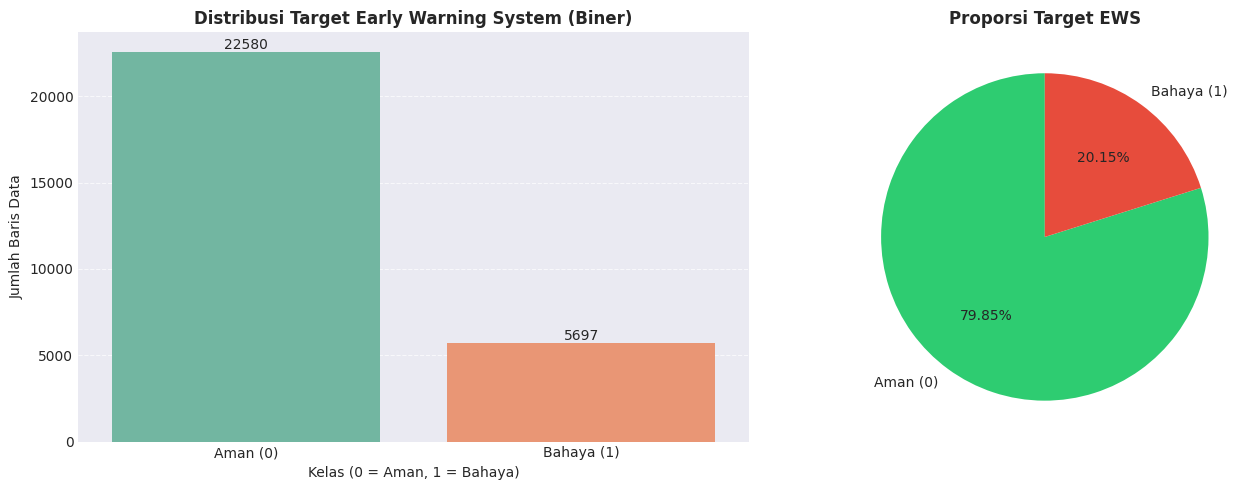

 Visualisasi tersimpan: /notebooks/output/01_distribusi_target.png

[SUMMARY TAHAP 1]
Data siap lanjut ke Tahap 2
• Dataset akhir: 28,277 baris × 25 kolom
• Target biner terbentuk (0: Aman, 1: Bahaya)
• Imbalance ratio: 0.2523


In [4]:
# 1.1 PEMUATAN DATA & PROFILING AWAL
print("\n[STEP 1.1] Pemuatan Data & Profiling Awal")
print("-" * 80)

path_data = os.path.join(DATA_PATH, 'asap_indonesia_master_2001.csv')
df = pd.read_csv(path_data)

print(f" Data berhasil dimuat.")
print(f"  Dimensi data mentah awal : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"  Memory usage             : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data type overview
print(f"\n[DATA PROFILING]")
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    # PERBAIKAN: Membungkus dtype dengan str() agar f-string tidak eror
    print(f"  • {str(dtype):<10}: {count} kolom")

# Missing values check
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100)
cols_with_missing = missing_counts[missing_counts > 0].sort_values(ascending=False)

if len(cols_with_missing) > 0:
    print(f"\n[MISSING VALUES AWAL] ({len(cols_with_missing)} kolom dengan missing)")
    for col, count in cols_with_missing.head(10).items():
        print(f"  • {col:<50}: {count:>6} ({missing_pct[col]:>5.2f}%)")
    if len(cols_with_missing) > 10:
        print(f"  ... dan {len(cols_with_missing)-10} kolom lainnya")
else:
    print(f"\n[MISSING VALUES] Tidak ada missing values di data mentah")

# Date range
df['date'] = pd.to_datetime(df['date'], errors='coerce')
print(f"\n[DATE RANGE]")
print(f"  • Mulai: {df['date'].min().date()}")
print(f"  • Akhir: {df['date'].max().date()}")
print(f"  • Total hari: {(df['date'].max() - df['date'].min()).days} hari")

# Unique regions
print(f"\n[GEOGRAPHIC COVERAGE]")
print(f"  • Total provinsi (unique region): {df['region_name'].nunique()}")
print(f"  • Contoh provinsi: {df['region_name'].unique()[:5].tolist()}")


# 1.2 FILTER DATA 'OFF SEASON'
print("\n[STEP 1.2] Filter Eliminasi 'Off Season'")
print("-" * 80)

df_before_filter = len(df)
df = df[df['w_crop_na'] != 'Off season'].copy()
df_after_filter = len(df)
eliminated = df_before_filter - df_after_filter

print(f" Filter 'Off season' berhasil.")
print(f"  Baris sebelum filter : {df_before_filter:,}")
print(f"  Baris setelah filter : {df_after_filter:,}")
print(f"  Baris dieliminasi    : {eliminated:,} ({eliminated/df_before_filter*100:.2f}%)")


# 1.3 TRANSFORMASI TARGET MENJADI BINER
print("\n[STEP 1.3] Transformasi Target ke Format Biner")
print("-" * 80)

def ubah_ke_biner(status):
    """
    Konversi w_crop_na status ke biner:
    0 = Aman (No warning)
    1 = Bahaya (exceptional, level 1-4)
    """
    status = str(status)
    if status == 'No warning': 
        return 0
    elif any(kategori in status for kategori in ['exceptional', 'level 1', 'level 2', 'level 3', 'level 4']): 
        return 1
    else: 
        return 0 

df['target_biner'] = df['w_crop_na'].apply(ubah_ke_biner)

print(f" Target biner berhasil dibuat.")
print(f"\n[DISTRIBUSI TARGET BINER]")
distribusi_target = df['target_biner'].value_counts().sort_index()
persentase_target = df['target_biner'].value_counts(normalize=True).sort_index() * 100

for kelas, jumlah in distribusi_target.items():
    label = "Aman (0)" if kelas == 0 else "Bahaya (1)"
    pct = persentase_target[kelas]
    bar = "█" * int(pct / 5)
    print(f"  {label:<15}: {jumlah:>7,} baris ({pct:>5.2f}%) {bar}")

imbalance_ratio = distribusi_target[1] / distribusi_target[0] if distribusi_target[0] > 0 else 0
print(f"\n  Rasio Imbalance (Bahaya:Aman) : {imbalance_ratio:.4f}")
if imbalance_ratio < 0.15:
    print(f"WARNING: Imbalance tinggi terdeteksi. Perlu handling di modeling stage.")
else:
    print(f"Imbalance manageable.")


# 1.4 VISUALISASI DISTRIBUSI TARGET
print("\n[STEP 1.4] Visualisasi Distribusi Target")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Count plot
sns.countplot(data=df, x='target_biner', palette='Set2', ax=axes[0])
axes[0].set_title('Distribusi Target Early Warning System (Biner)', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kelas (0 = Aman, 1 = Bahaya)', fontsize=10)
axes[0].set_ylabel('Jumlah Baris Data', fontsize=10)
axes[0].set_xticklabels(['Aman (0)', 'Bahaya (1)'])
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Tambah value labels
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# Plot 2: Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(distribusi_target, labels=['Aman (0)', 'Bahaya (1)'], 
            autopct='%1.2f%%', colors=colors, startangle=90, 
            textprops={'fontsize': 10})
axes[1].set_title('Proporsi Target EWS', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '01_distribusi_target.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

print(f" Visualisasi tersimpan: {os.path.join(OUTPUT_PATH, '01_distribusi_target.png')}")


# 1.5 SUMMARY TAHAP 1
print("\n[SUMMARY TAHAP 1]")
print("="*80)
print(f"Data siap lanjut ke Tahap 2")
print(f"• Dataset akhir: {len(df):,} baris × {df.shape[1]} kolom")
print(f"• Target biner terbentuk (0: Aman, 1: Bahaya)")
print(f"• Imbalance ratio: {imbalance_ratio:.4f}")
print("="*80)

### 2A. EKSTRAKSI TEMPORAL & IMPUTASI DASAR

In [5]:
# 2A.1 EKSTRAKSI FITUR WAKTU DASAR
print("\n[STEP 2A.1] Ekstraksi Fitur Waktu Dasar")
print("-" * 80)

# Parsing date (sudah dilakukan di cell 1, tapi validasi ulang)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Ekstraksi fitur waktu
df['year_extracted'] = df['date'].dt.year
df['month_extracted'] = df['date'].dt.month
df['quarter_extracted'] = df['date'].dt.quarter
df['semester_extracted'] = ((df['date'].dt.month - 1) // 6) + 1

print(f"Fitur waktu dasar berhasil diekstrak.")
print(f"  • year_extracted   : {df['year_extracted'].min():.0f} - {df['year_extracted'].max():.0f}")
print(f"  • month_extracted  : 1 - 12")
print(f"  • quarter_extracted: 1 - 4")
print(f"  • semester_extracted: 1 - 2")


# 2A.2 PENGECEKAN MISSING VALUES SEBELUM IMPUTASI
# ============================================================================
print("\n[STEP 2A.2] Pengecekan Missing Values Sebelum Imputasi")
print("-" * 80)

kolom_soil = 'Soil Moisture (gapfilled historical time series)'
kolom_numerical = [
    'Rainfall', 'Temperature', kolom_soil, 'SPI - 3 months', 
    'Water Satisfaction Index (WSI)', 'Solar Radiation', 'FPAR', 'FPAR - zscore'
]

missing_before = {}
for col in kolom_numerical:
    if col in df.columns:
        missing_count = df[col].isnull().sum()
        missing_pct = missing_count / len(df) * 100
        missing_before[col] = missing_count
        if missing_count > 0:
            print(f"  • {col:<50}: {missing_count:>6} ({missing_pct:>5.2f}%)")

total_missing = sum(missing_before.values())
if total_missing == 0:
    print(f"Tidak ada missing values pada kolom numerik.")
else:
    print(f"  Total missing values: {total_missing:,}")


# 2A.3 IMPUTASI MEDIAN PER REGION (PROVINSI)
# ============================================================================
print("\n[STEP 2A.3] Imputasi Median Per Region (Domain-Aware)")
print("-" * 80)

# Sorting untuk memastikan urutan temporal
df = df.sort_values(['region_name', 'date']).reset_index(drop=True)

print(f"Data disort by region & date")

# Imputasi per region menggunakan median
for col in kolom_numerical:
    if col in df.columns:
        df[col] = df.groupby('region_name')[col].transform(
            lambda x: x.fillna(x.median())
        )

# Fallback global jika ada region dengan semua values kosong
for col in kolom_numerical:
    if col in df.columns:
        global_median = df[col].median()
        df[col] = df[col].fillna(global_median)

print(f"Imputasi median per region berhasil.")
print(f"  Kolom yang diimputasi: {len(kolom_numerical)}")


# 2A.4 VALIDASI IMPUTASI
# ============================================================================
print("\n[STEP 2A.4] Validasi Imputasi")
print("-" * 80)

missing_after = {}
for col in kolom_numerical:
    if col in df.columns:
        missing_count = df[col].isnull().sum()
        missing_after[col] = missing_count

total_missing_after = sum(missing_after.values())
if total_missing_after == 0:
    print(f"Imputasi BERHASIL. Tidak ada missing values.")
    print(f"Status: PASS")
else:
    print(f"{total_missing_after} missing values masih ada:")
    for col, count in missing_after.items():
        if count > 0:
            print(f"  • {col}: {count}")


# 2A.5 SUMMARY TAHAP 2A
# ============================================================================
print("\n[SUMMARY TAHAP 2A]")
print("="*80)
print(f"Temporal ekstraksi & imputasi dasar selesai")
print(f"   • Fitur waktu: year, month, quarter, semester")
print(f"   • Missing values: {missing_before.get(kolom_soil, 0)} → {missing_after.get(kolom_soil, 0)}")
print("="*80)


[STEP 2A.1] Ekstraksi Fitur Waktu Dasar
--------------------------------------------------------------------------------
Fitur waktu dasar berhasil diekstrak.
  • year_extracted   : 2001 - 2026
  • month_extracted  : 1 - 12
  • quarter_extracted: 1 - 4
  • semester_extracted: 1 - 2

[STEP 2A.2] Pengecekan Missing Values Sebelum Imputasi
--------------------------------------------------------------------------------
  • Soil Moisture (gapfilled historical time series)  :    961 ( 3.40%)
  Total missing values: 961

[STEP 2A.3] Imputasi Median Per Region (Domain-Aware)
--------------------------------------------------------------------------------
Data disort by region & date
Imputasi median per region berhasil.
  Kolom yang diimputasi: 8

[STEP 2A.4] Validasi Imputasi
--------------------------------------------------------------------------------
Imputasi BERHASIL. Tidak ada missing values.
Status: PASS

[SUMMARY TAHAP 2A]
Temporal ekstraksi & imputasi dasar selesai
   • Fitur waktu

### 2B. TEMPORAL FEATURE ENGINEERING (LAGGED & ROLLING)

In [6]:
# 2B.1 PEMBUATAN LAGGED FEATURES
# ============================================================================
print("\n[STEP 2B.1] Pembuatan Lagged Features (Lag 1, 3, 6 Bulan)")
print("-" * 80)

# Fitur yang akan di-lag
fitur_lag = ['Rainfall', 'Temperature', kolom_soil, 'Water Satisfaction Index (WSI)']
lag_periods = [1, 3, 6]

print(f"Membuat lagged features:")
print(f"  Fitur yang di-lag: {len(fitur_lag)}")
print(f"  Lag periods: {lag_periods}")

# REVISED: Check fitur ada atau tidak sebelum lag
fitur_lag_valid = [col for col in fitur_lag if col in df.columns]
print(f"  Fitur valid untuk lag: {len(fitur_lag_valid)}/{len(fitur_lag)}")

for col in fitur_lag_valid:
    for lag in lag_periods:
        lag_col_name = f'{col}_lag_{lag}'
        df[lag_col_name] = df.groupby('region_name')[col].shift(lag)

total_lag_features = len(fitur_lag_valid) * len(lag_periods)
print(f"\n Total lagged features terbuat: {total_lag_features} kolom")


# 2B.2 PEMBUATAN ROLLING STATISTICS
# ============================================================================
print("\n[STEP 2B.2] Pembuatan Rolling Statistics (30, 90 Hari)")
print("-" * 80)

fitur_rolling = ['Rainfall', kolom_soil, 'Water Satisfaction Index (WSI)']
window_sizes = [30, 90]

print(f"Membuat rolling statistics:")
print(f"  Fitur: {len(fitur_rolling)}")
print(f"  Window sizes: {window_sizes}")

# REVISED: Check fitur ada
fitur_rolling_valid = [col for col in fitur_rolling if col in df.columns]

for col in fitur_rolling_valid:
    for window in window_sizes:
        # Rolling mean
        roll_mean_name = f'{col}_roll_mean_{window}'
        df[roll_mean_name] = df.groupby('region_name')[col].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )
        
        # Rolling std
        roll_std_name = f'{col}_roll_std_{window}'
        df[roll_std_name] = df.groupby('region_name')[col].transform(
            lambda x: x.rolling(window=window, min_periods=1).std()
        )

total_rolling_features = len(fitur_rolling_valid) * len(window_sizes) * 2
print(f"\n Total rolling features terbuat: {total_rolling_features} kolom")


# 2B.3 FORWARD FILL UNTUK HANDLING NaN SETELAH LAG
# ============================================================================
print("\n[STEP 2B.3] Forward Fill untuk NaN Setelah Lag Operation")
print("-" * 80)

# Cek NaN setelah lag
nan_before_ff = df.isnull().sum().sum()
print(f" Total NaN sebelum forward fill: {nan_before_ff:,}")

# Forward fill per region
print(f"Applying forward fill per region...")
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df.groupby('region_name')[col].transform(
            lambda x: x.fillna(method='ffill').fillna(method='bfill')
        )

# Fallback: fill sisa dengan median
for col in df.columns:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

nan_after_ff = df.isnull().sum().sum()
print(f"Forward fill selesai. NaN tersisa: {nan_after_ff}")


# 2B.4 STATISTIK TEMPORAL FEATURES
# ============================================================================
print("\n[STEP 2B.4] Statistik Temporal Features")
print("-" * 80)

temporal_base_count = 4  # year, month, quarter, semester
total_temporal_features = temporal_base_count + total_lag_features + total_rolling_features

print(f"Statistik Fitur Temporal:")
print(f"  • Fitur temporal dasar : {temporal_base_count}")
print(f"  • Fitur lagged         : {total_lag_features}")
print(f"  • Fitur rolling stats  : {total_rolling_features}")
print(f"  • Total temporal features: {total_temporal_features}")

print(f"\n Dimensi dataset setelah temporal engineering:")
print(f"  Baris: {df.shape[0]:,} | Kolom: {df.shape[1]}")


# 2B.5 CONTOH DATA SETELAH TEMPORAL ENGINEERING
# ============================================================================
print("\n[STEP 2B.5] Sample Data Setelah Temporal Engineering")
print("-" * 80)

sample_region = df['region_name'].unique()[0]
sample_cols = ['region_name', 'date', 'Rainfall', 'Rainfall_lag_1', 
               'Rainfall_lag_3', 'Rainfall_roll_mean_30', 'Rainfall_roll_std_30']
sample_cols_exist = [col for col in sample_cols if col in df.columns]

sample_data = df[df['region_name'] == sample_region].head(10)[sample_cols_exist]

print(f"Sample data untuk region: {sample_region}")
print(sample_data.to_string(index=False))


# 2B.6 SUMMARY TAHAP 2B
# ============================================================================
print("\n[SUMMARY TAHAP 2B]")
print("="*80)
print(f"Temporal Feature Engineering selesai")
print(f"   • Lagged features: {total_lag_features} kolom")
print(f"   • Rolling statistics: {total_rolling_features} kolom")
print(f"   • Total temporal features: {total_temporal_features} kolom")
print(f"   • NaN values: {nan_after_ff} (cleaned)")
print("="*80)


[STEP 2B.1] Pembuatan Lagged Features (Lag 1, 3, 6 Bulan)
--------------------------------------------------------------------------------
Membuat lagged features:
  Fitur yang di-lag: 4
  Lag periods: [1, 3, 6]
  Fitur valid untuk lag: 4/4

 Total lagged features terbuat: 12 kolom

[STEP 2B.2] Pembuatan Rolling Statistics (30, 90 Hari)
--------------------------------------------------------------------------------
Membuat rolling statistics:
  Fitur: 3
  Window sizes: [30, 90]

 Total rolling features terbuat: 12 kolom

[STEP 2B.3] Forward Fill untuk NaN Setelah Lag Operation
--------------------------------------------------------------------------------
 Total NaN sebelum forward fill: 1,518
Applying forward fill per region...
Forward fill selesai. NaN tersisa: 0

[STEP 2B.4] Statistik Temporal Features
--------------------------------------------------------------------------------
Statistik Fitur Temporal:
  • Fitur temporal dasar : 4
  • Fitur lagged         : 12
  • Fitur roll

### 3. PENANGANAN OUTLIER (IQR CAPPING)


[STEP 3.1] Identifikasi Outlier Menggunakan IQR Method
--------------------------------------------------------------------------------
 Menghitung IQR bounds untuk 8 fitur:

Fitur                                         Min (Awal)   Max (Awal)   Outliers  
--------------------------------------------------------------------------------
Rainfall                                      1.07         440.80       262        (0.93%)
Temperature                                   19.16        29.33        1051       (3.72%)
Soil Moisture (gapfilled historical time series) 0.09         0.46         1059       (3.75%)
SPI - 3 months                                -2.49        2.50         18         (0.06%)
Water Satisfaction Index (WSI)                25.65        100.00       3848       (13.61%)
Solar Radiation                               88976.13     275264.09    273        (0.97%)
FPAR                                          16.60        79.40        911        (3.22%)
FPAR - zscore      

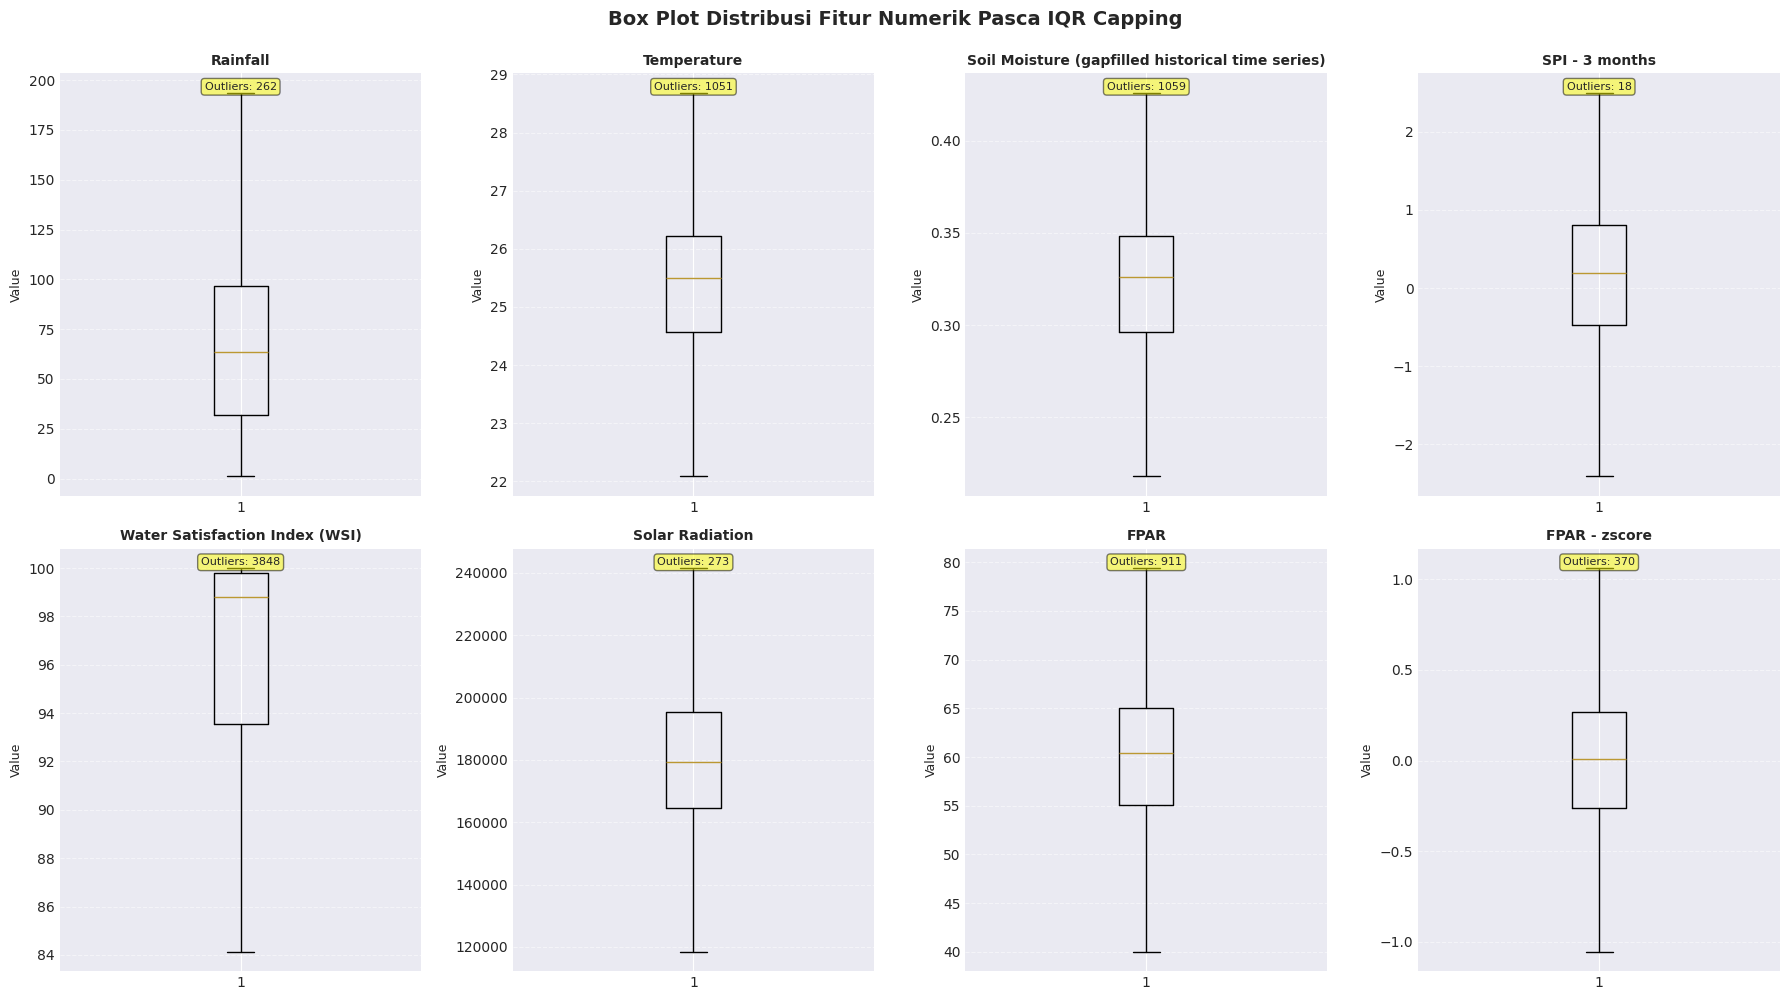

 Visualisasi tersimpan: /notebooks/output/02_boxplot_outliers.png

[STEP 3.5] Visualisasi Matriks Korelasi Heatmap
--------------------------------------------------------------------------------


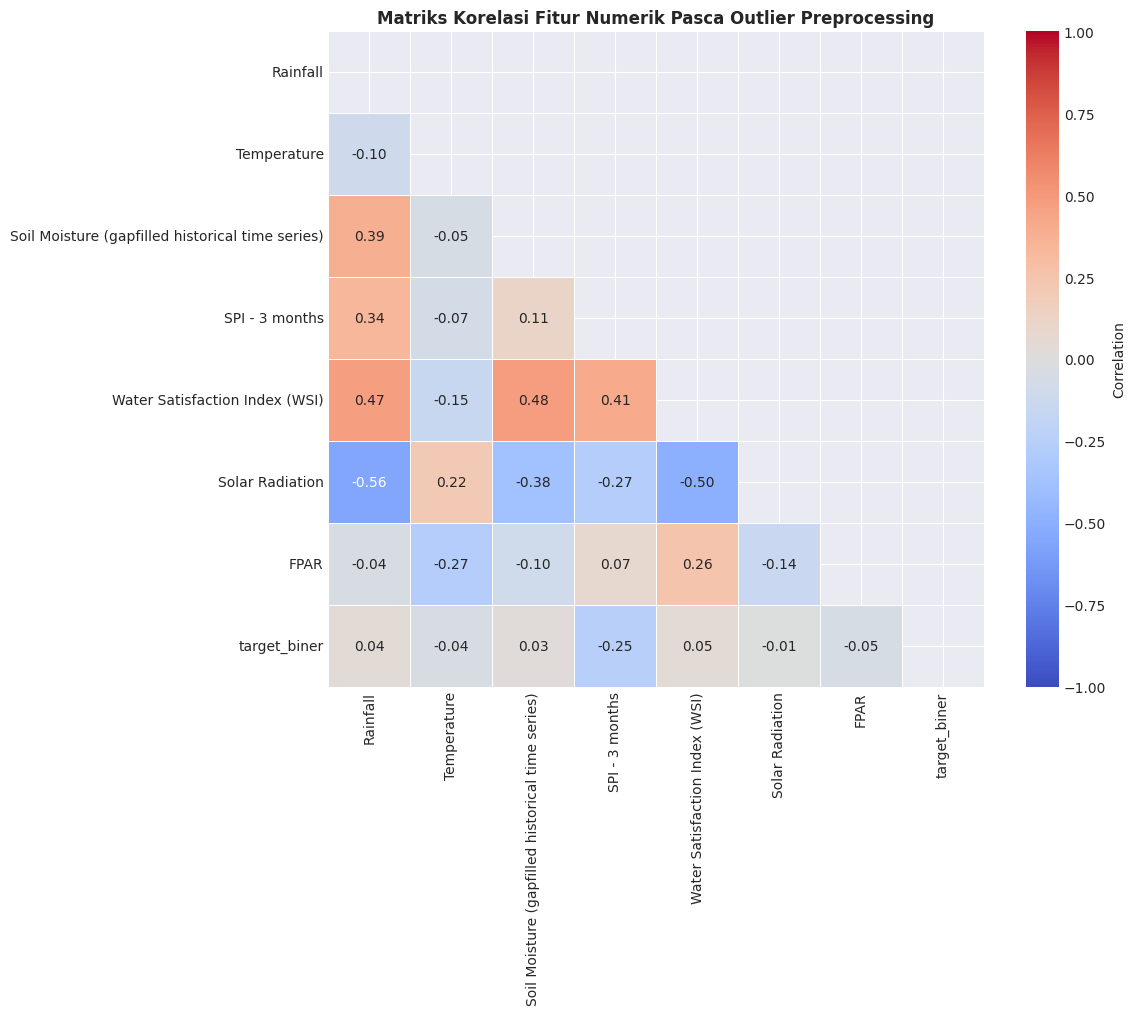

 Visualisasi tersimpan: /notebooks/output/03_correlation_heatmap.png

[SUMMARY TAHAP 3]
Penanganan outlier selesai
   • Total fitur yang di-cap: 8
   • Total outliers dihilangkan: 7792
   • Extreme events preserved untuk EWS validity


In [7]:
# 3.1 IDENTIFIKASI OUTLIER & PERHITUNGAN BOUND
# ============================================================================
print("\n[STEP 3.1] Identifikasi Outlier Menggunakan IQR Method")
print("-" * 80)

fitur_numerik = [
    'Rainfall', 'Temperature', kolom_soil, 
    'SPI - 3 months', 'Water Satisfaction Index (WSI)', 'Solar Radiation', 
    'FPAR', 'FPAR - zscore'
]

# Filter kolom yang ada
fitur_numerik = [col for col in fitur_numerik if col in df.columns]

outlier_stats = {}

print(f" Menghitung IQR bounds untuk {len(fitur_numerik)} fitur:")
print(f"\n{'Fitur':<45} {'Min (Awal)':<12} {'Max (Awal)':<12} {'Outliers':<10}")
print("-" * 80)

for col in fitur_numerik:
    min_awal = df[col].min()
    max_awal = df[col].max()
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Hitung jumlah outlier
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_pct = outlier_count / len(df) * 100
    
    # Simpan stats
    outlier_stats[col] = {
        'min_awal': min_awal,
        'max_awal': max_awal,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': outlier_count,
        'outlier_pct': outlier_pct,
        'IQR': IQR,
        'Q1': Q1,
        'Q3': Q3
    }
    
    print(f"{col:<45} {min_awal:<12.2f} {max_awal:<12.2f} {outlier_count:<10} ({outlier_pct:.2f}%)")


# 3.2 EKSEKUSI IQR CAPPING
# ============================================================================
print("\n[STEP 3.2] Eksekusi IQR Capping (Pembatasan Nilai)")
print("-" * 80)

for col in fitur_numerik:
    lower_bound = outlier_stats[col]['lower_bound']
    upper_bound = outlier_stats[col]['upper_bound']
    
    # Capping
    df[col] = np.clip(df[col], lower_bound, upper_bound)

print(f" IQR capping berhasil untuk {len(fitur_numerik)} fitur")


# 3.3 VALIDASI SEBELUM-SESUDAH CAPPING
# ============================================================================
print("\n[STEP 3.3] Perbandingan Nilai Ekstrem Sebelum & Sesudah Capping")
print("-" * 80)

print(f"\n{'Fitur':<45} {'Rentang Awal':<25} {'Rentang Akhir':<25} {'Outliers':<10}")
print("-" * 105)

for col in fitur_numerik:
    min_awal = outlier_stats[col]['min_awal']
    max_awal = outlier_stats[col]['max_awal']
    min_akhir = df[col].min()
    max_akhir = df[col].max()
    outliers = outlier_stats[col]['outlier_count']
    
    rentang_awal = f"[{min_awal:.2f} - {max_awal:.2f}]"
    rentang_akhir = f"[{min_akhir:.2f} - {max_akhir:.2f}]"
    
    print(f"{col:<45} {rentang_awal:<25} {rentang_akhir:<25} {outliers:<10}")


# 3.4 VISUALISASI BOX PLOT
# ============================================================================
print("\n[STEP 3.4] Visualisasi Box Plot (Outlier Distribution)")
print("-" * 80)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(fitur_numerik):
    axes[idx].boxplot(df[col], vert=True)
    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Value', fontsize=9)
    axes[idx].grid(axis='y', linestyle='--', alpha=0.5)
    
    outlier_count = outlier_stats[col]['outlier_count']
    axes[idx].text(0.5, 0.98, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, ha='center', va='top',
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5), fontsize=8)

# Hide unused subplots jika kurang dari 8 fitur
for idx in range(len(fitur_numerik), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Box Plot Distribusi Fitur Numerik Pasca IQR Capping', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '02_boxplot_outliers.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

print(f" Visualisasi tersimpan: {os.path.join(OUTPUT_PATH, '02_boxplot_outliers.png')}")


# 3.5 VISUALISASI KORELASI HEATMAP
# ============================================================================
print("\n[STEP 3.5] Visualisasi Matriks Korelasi Heatmap")
print("-" * 80)

fitur_untuk_korelasi = [
    'Rainfall', 'Temperature', kolom_soil, 'SPI - 3 months',
    'Water Satisfaction Index (WSI)', 'Solar Radiation', 'FPAR', 'target_biner'
]
fitur_untuk_korelasi = [col for col in fitur_untuk_korelasi if col in df.columns]

korelasi = df[fitur_untuk_korelasi].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(korelasi, dtype=bool))
sns.heatmap(korelasi, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, cbar_kws={'label': 'Correlation'},
            linewidths=0.5)
plt.title('Matriks Korelasi Fitur Numerik Pasca Outlier Preprocessing', 
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '03_correlation_heatmap.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

print(f" Visualisasi tersimpan: {os.path.join(OUTPUT_PATH, '03_correlation_heatmap.png')}")


# 3.6 SUMMARY TAHAP 3
# ============================================================================
print("\n[SUMMARY TAHAP 3]")
print("="*80)
print(f"Penanganan outlier selesai")
print(f"   • Total fitur yang di-cap: {len(fitur_numerik)}")
print(f"   • Total outliers dihilangkan: {sum([s['outlier_count'] for s in outlier_stats.values()])}")
print(f"   • Extreme events preserved untuk EWS validity")
print("="*80)

### 4A. K-MEANS CLUSTERING GEOGRAFIS


TAHAP 4A: K-MEANS CLUSTERING GEOGRAFIS (K=3)

[STEP 4A.1] Agregasi Data per Provinsi (Region)
--------------------------------------------------------------------------------
Agregasi berhasil.
  Total provinsi: 33
  Fitur iklim yang diagregasi: 3

[PROVINSI & KARAKTERISTIK IKLIM] (Top 10)

Provinsi                       Rainfall        Temperature     Soil Moisture  
---------------------------------------------------------------------------
Bali                           53.66           24.19           0.26           
Bangka Belitung                71.82           26.82           0.23           
Banten                         74.93           26.10           0.36           
Bengkulu                       80.95           23.51           0.32           
D.I. Yogyakarta                68.59           25.49           0.27           
Dki Jakarta                    52.62           26.89           0.39           
Gorontalo                      50.55           25.19           0.29           

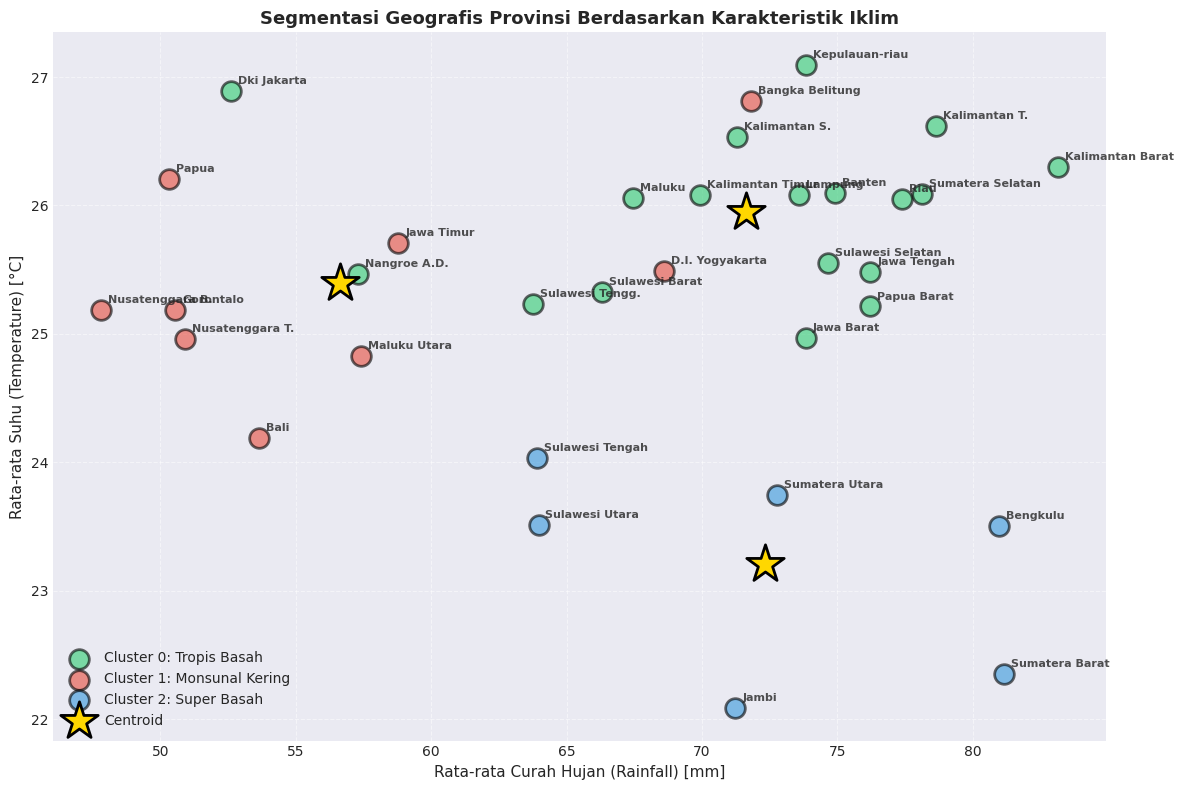

 Visualisasi tersimpan: /notebooks/output/04_clustering_scatter.png

[SUMMARY TAHAP 4A]
K-Means clustering K=3 selesai
   • Total provinsi: 33
   • Cluster terbentuk: 3 (dengan interpretasi domain iklim)
   • Dataset dengan cluster label: 28,277 baris


In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("\n" + "="*80)
print("TAHAP 4A: K-MEANS CLUSTERING GEOGRAFIS (K=3)")
print("="*80)


# 4A.1 AGREGASI DATA PER PROVINSI
# ============================================================================
print("\n[STEP 4A.1] Agregasi Data per Provinsi (Region)")
print("-" * 80)

fitur_iklim = ['Rainfall', 'Temperature', kolom_soil]
fitur_iklim = [col for col in fitur_iklim if col in df.columns]

df_provinsi = df.groupby('region_name')[fitur_iklim].mean().reset_index()

print(f"Agregasi berhasil.")
print(f"  Total provinsi: {len(df_provinsi)}")
print(f"  Fitur iklim yang diagregasi: {len(fitur_iklim)}")

print(f"\n[PROVINSI & KARAKTERISTIK IKLIM] (Top 10)")
print(f"\n{'Provinsi':<30} {'Rainfall':<15} {'Temperature':<15} {'Soil Moisture':<15}")
print("-" * 75)
for _, row in df_provinsi.head(10).iterrows():
    rainfall = row['Rainfall'] if 'Rainfall' in fitur_iklim else 0
    temp = row['Temperature'] if 'Temperature' in fitur_iklim else 0
    soil = row[kolom_soil] if kolom_soil in fitur_iklim else 0
    print(f"{row['region_name']:<30} {rainfall:<15.2f} {temp:<15.2f} {soil:<15.2f}")

if len(df_provinsi) > 10:
    print(f"... (dan {len(df_provinsi)-10} provinsi lainnya)")


# 4A.2 STANDARISASI FITUR KLASTER
# ============================================================================
print("\n[STEP 4A.2] Standarisasi Fitur Clustering (StandardScaler)")
print("-" * 80)

scaler_cluster = StandardScaler()
fitur_iklim_scaled = scaler_cluster.fit_transform(df_provinsi[fitur_iklim])

print(f"Standarisasi fitur berhasil.")
print(f"  Mean scaled features: {fitur_iklim_scaled.mean(axis=0).round(4)}")
print(f"  Std scaled features : {fitur_iklim_scaled.std(axis=0).round(4)}")


# 4A.3 EKSEKUSI K-MEANS K=3
# ============================================================================
print("\n[STEP 4A.3] Eksekusi K-Means Clustering (K=3)")
print("-" * 80)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_provinsi['Cluster_Wilayah'] = kmeans.fit_predict(fitur_iklim_scaled)

inertia = kmeans.inertia_
print(f"K-Means K=3 berhasil dilatih.")
print(f"  Inertia (SSE): {inertia:.4f}")
print(f"  Centroid shape: {kmeans.cluster_centers_.shape}")


# 4A.4 DAFTAR ANGGOTA CLUSTER & PROVINSI
# ============================================================================
print("\n[STEP 4A.4] Daftar Anggota Cluster Wilayah")
print("-" * 80)

cluster_interpretations = {
    0: "Tropis Basah - Curah hujan tinggi, suhu stabil tinggi, kelembapan tanah optimal",
    1: "Monsunal Kering - Curah hujan rendah-sedang, suhu tinggi fluktuatif, kelembapan tanah rendah",
    2: "Super Basah (Pegunungan) - Curah hujan sangat tinggi, suhu lebih rendah, kelembapan tanah sangat tinggi"
}

for i in range(3):
    anggota_provinsi = df_provinsi[df_provinsi['Cluster_Wilayah'] == i]['region_name'].tolist()
    n_provinsi = len(anggota_provinsi)
    
    # Hitung karakteristik cluster
    cluster_data = df_provinsi[df_provinsi['Cluster_Wilayah'] == i][fitur_iklim]
    mean_rainfall = cluster_data['Rainfall'].mean() if 'Rainfall' in fitur_iklim else 0
    mean_temp = cluster_data['Temperature'].mean() if 'Temperature' in fitur_iklim else 0
    mean_soil = cluster_data[kolom_soil].mean() if kolom_soil in fitur_iklim else 0
    
    print(f"\n[CLUSTER {i}] ({n_provinsi} Provinsi)")
    print(f"  Interpretasi Domain: {cluster_interpretations[i]}")
    print(f"  Karakteristik:")
    print(f"    • Rainfall rata-rata      : {mean_rainfall:.2f} mm")
    print(f"    • Temperature rata-rata   : {mean_temp:.2f} °C")
    print(f"    • Soil Moisture rata-rata : {mean_soil:.2f}")
    print(f"  Anggota provinsi:")
    for j, prov in enumerate(anggota_provinsi, 1):
        print(f"    {j:2}. {prov}")


# 4A.5 MERGE CLUSTER LABEL KE DATASET UTAMA
# ============================================================================
print("\n[STEP 4A.5] Merge Cluster Label ke Dataset Utama")
print("-" * 80)

if 'Cluster_Wilayah' in df.columns:
    df = df.drop(columns=['Cluster_Wilayah'])

df = df.merge(df_provinsi[['region_name', 'Cluster_Wilayah']], 
              on='region_name', how='left')

print(f"Merge berhasil.")
print(f"  Dataset dimension: {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"  Cluster label terdistribusi:")
for i in range(3):
    count = (df['Cluster_Wilayah'] == i).sum()
    pct = count / len(df) * 100
    print(f"    Cluster {i}: {count:>7,} baris ({pct:>5.2f}%)")


# 4A.6 VISUALISASI SCATTER PLOT CLUSTER
# ============================================================================
print("\n[STEP 4A.6] Visualisasi Scatter Plot Rainfall vs Temperature")
print("-" * 80)

plt.figure(figsize=(12, 8))
colors = ['#2ecc71', '#e74c3c', '#3498db']
cluster_names = [
    'Cluster 0: Tropis Basah', 
    'Cluster 1: Monsunal Kering', 
    'Cluster 2: Super Basah'
]

for i in range(3):
    cluster_data = df_provinsi[df_provinsi['Cluster_Wilayah'] == i]
    plt.scatter(cluster_data['Rainfall'], cluster_data['Temperature'], 
               s=200, alpha=0.6, color=colors[i], label=cluster_names[i], 
               edgecolors='black', linewidth=2)
    
    # Annotate provinsi
    for _, row in cluster_data.iterrows():
        plt.annotate(row['region_name'], 
                    xy=(row['Rainfall'], row['Temperature']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.8, fontweight='bold')

# Plot centroid
centroids_denormalized = scaler_cluster.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_denormalized[:, 0], centroids_denormalized[:, 1],
           s=800, c='gold', marker='*', edgecolors='black', linewidth=2,
           label='Centroid', zorder=5)

plt.title('Segmentasi Geografis Provinsi Berdasarkan Karakteristik Iklim', 
         fontsize=13, fontweight='bold')
plt.xlabel('Rata-rata Curah Hujan (Rainfall) [mm]', fontsize=11)
plt.ylabel('Rata-rata Suhu (Temperature) [°C]', fontsize=11)
plt.legend(loc='best', fontsize=10, framealpha=0.95)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '04_clustering_scatter.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

print(f" Visualisasi tersimpan: {os.path.join(OUTPUT_PATH, '04_clustering_scatter.png')}")


# 4A.7 SUMMARY TAHAP 4A
# ============================================================================
print("\n[SUMMARY TAHAP 4A]")
print("="*80)
print(f"K-Means clustering K=3 selesai")
print(f"   • Total provinsi: {len(df_provinsi)}")
print(f"   • Cluster terbentuk: 3 (dengan interpretasi domain iklim)")
print(f"   • Dataset dengan cluster label: {df.shape[0]:,} baris")
print("="*80)

### 4B. PROFIL KARAKTERISTIK CLUSTER


[STEP 4B.1] Perhitungan Rata-Rata Karakteristik Per Cluster
--------------------------------------------------------------------------------
Profil cluster berhasil dihitung.

[PROFIL KARAKTERISTIK IKLIM PER CLUSTER]
Cluster_Wilayah                                        0       1       2
Rainfall                                          71.583  56.478  72.266
Temperature                                       25.947  25.384  23.219
Soil Moisture (gapfilled historical time series)   0.335   0.274   0.333

[STEP 4B.2] Visualisasi Bar Chart Profil Iklim
--------------------------------------------------------------------------------


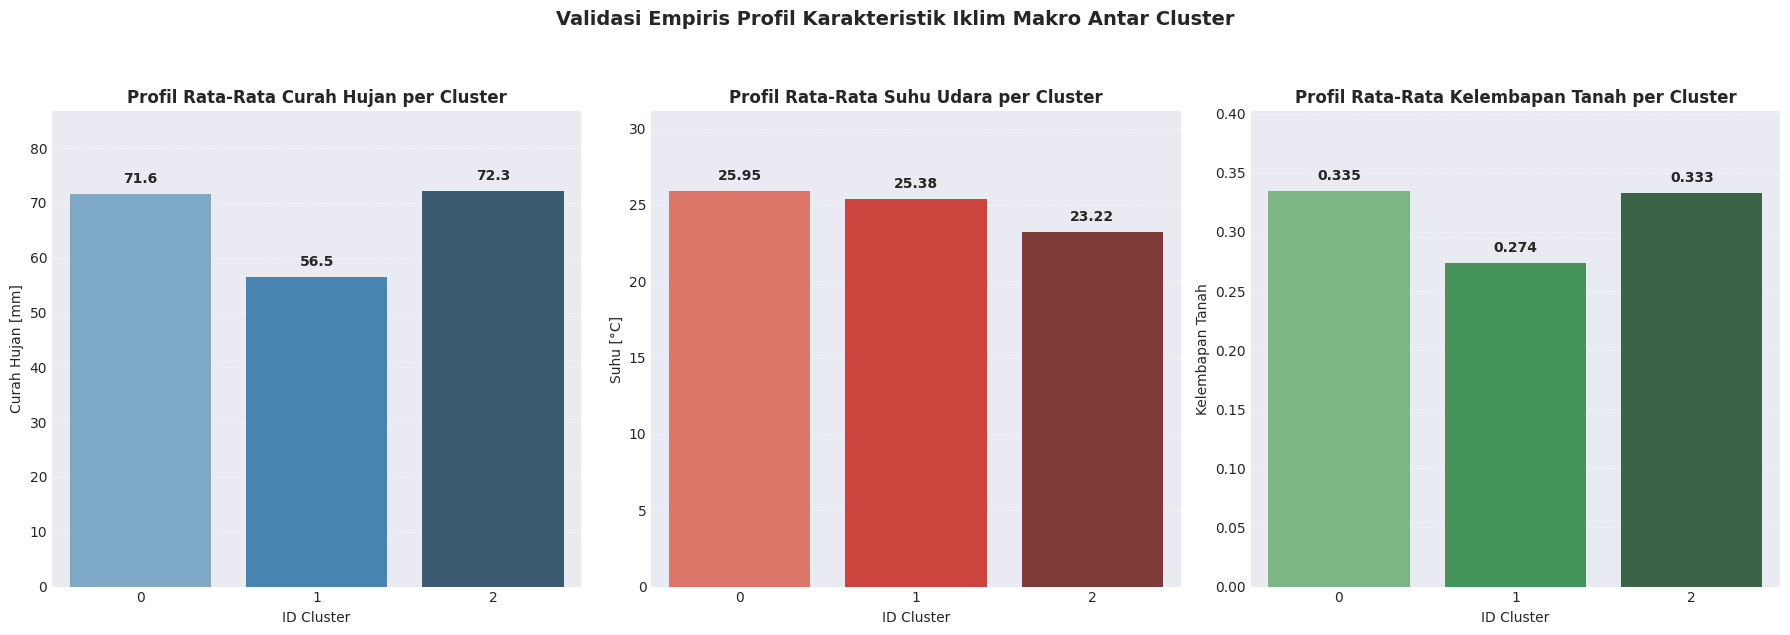

 Visualisasi tersimpan: /notebooks/output/05_cluster_profiles_barchart.png

[SUMMARY TAHAP 4B]
Profil cluster characteristics terbukti
   • Cluster 0 (Tropis Basah): Rainfall=71.58, Temp=25.95
   • Cluster 1 (Monsunal Kering): Rainfall=56.48, Temp=25.38
   • Cluster 2 (Super Basah): Rainfall=72.27, Temp=23.22


In [14]:
# 4B.1 PERHITUNGAN RATA-RATA PROFIL PER CLUSTER
# ============================================================================
print("\n[STEP 4B.1] Perhitungan Rata-Rata Karakteristik Per Cluster")
print("-" * 80)

cluster_profile = df.groupby('Cluster_Wilayah')[fitur_iklim].mean(numeric_only=True).reset_index()

print(f"Profil cluster berhasil dihitung.")
print(f"\n[PROFIL KARAKTERISTIK IKLIM PER CLUSTER]")
tabel_rapi = cluster_profile.set_index('Cluster_Wilayah').T.round(3)
print(tabel_rapi.to_string())


# 4B.2 VISUALISASI BAR CHART 3 VARIABEL IKLIM
# ============================================================================
print("\n[STEP 4B.2] Visualisasi Bar Chart Profil Iklim")
print("-" * 80)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Rainfall
if 'Rainfall' in cluster_profile.columns:
    sns.barplot(data=cluster_profile, x='Cluster_Wilayah', y='Rainfall', 
                ax=axes[0], palette='Blues_d')
    axes[0].set_title('Profil Rata-Rata Curah Hujan per Cluster', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('ID Cluster', fontsize=10)
    axes[0].set_ylabel('Curah Hujan [mm]', fontsize=10)
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)
    
    # PERBAIKAN: Menambah batas atas grafik (margin 20%) agar teks tidak nabrak
    max_val = cluster_profile['Rainfall'].max()
    axes[0].set_ylim(0, max_val * 1.2)
    
    # Suntik teks manual dengan 1 desimal
    for i, v in enumerate(cluster_profile['Rainfall']):
        axes[0].text(i, v + (max_val * 0.02), f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Temperature
if 'Temperature' in cluster_profile.columns:
    sns.barplot(data=cluster_profile, x='Cluster_Wilayah', y='Temperature', 
                ax=axes[1], palette='Reds_d')
    axes[1].set_title('Profil Rata-Rata Suhu Udara per Cluster', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('ID Cluster', fontsize=10)
    axes[1].set_ylabel('Suhu [°C]', fontsize=10)
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)
    
    max_val = cluster_profile['Temperature'].max()
    axes[1].set_ylim(0, max_val * 1.2)
    
    # Suntik teks manual dengan 2 desimal
    for i, v in enumerate(cluster_profile['Temperature']):
        axes[1].text(i, v + (max_val * 0.02), f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Soil Moisture
if kolom_soil in cluster_profile.columns:
    sns.barplot(data=cluster_profile, x='Cluster_Wilayah', y=kolom_soil, 
                ax=axes[2], palette='Greens_d')
    axes[2].set_title('Profil Rata-Rata Kelembapan Tanah per Cluster', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('ID Cluster', fontsize=10)
    axes[2].set_ylabel('Kelembapan Tanah', fontsize=10)
    axes[2].grid(axis='y', linestyle='--', alpha=0.5)
    
    max_val = cluster_profile[kolom_soil].max()
    axes[2].set_ylim(0, max_val * 1.2)
    
    # Suntik teks manual dengan 3 desimal agar nilai kecil (0.015 dll) tetap terbaca
    for i, v in enumerate(cluster_profile[kolom_soil]):
        axes[2].text(i, v + (max_val * 0.02), f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Validasi Empiris Profil Karakteristik Iklim Makro Antar Cluster', 
            fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '05_cluster_profiles_barchart.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f" Visualisasi tersimpan: {os.path.join(OUTPUT_PATH, '05_cluster_profiles_barchart.png')}")


# 4B.3 SUMMARY TAHAP 4B
# ============================================================================
print("\n[SUMMARY TAHAP 4B]")
print("="*80)
print(f"Profil cluster characteristics terbukti")
if 'Rainfall' in cluster_profile.columns and 'Temperature' in cluster_profile.columns:
    print(f"   • Cluster 0 (Tropis Basah): Rainfall={cluster_profile.loc[0, 'Rainfall']:.2f}, Temp={cluster_profile.loc[0, 'Temperature']:.2f}")
    print(f"   • Cluster 1 (Monsunal Kering): Rainfall={cluster_profile.loc[1, 'Rainfall']:.2f}, Temp={cluster_profile.loc[1, 'Temperature']:.2f}")
    print(f"   • Cluster 2 (Super Basah): Rainfall={cluster_profile.loc[2, 'Rainfall']:.2f}, Temp={cluster_profile.loc[2, 'Temperature']:.2f}")
print("="*80)

### 4C. SILHOUETTE SCORE EVALUATION


[STEP 4C.1] Persiapan Data untuk Silhouette Analysis
--------------------------------------------------------------------------------
Data persiapan berhasil.
  Jumlah sampel (provinsi): 33
  Jumlah fitur: 3
  Jumlah cluster: 3

[STEP 4C.2] Perhitungan Silhouette Score Global (K=3)
--------------------------------------------------------------------------------
Silhouette score berhasil dihitung.

[METRIK VALIDASI CLUSTER]
  Rata-rata Silhouette Score (K=3): 0.3916
  Status Validasi: GOOD - Struktur cluster stabil (memenuhi syarat)

[STEP 4C.3] Perhitungan Silhouette Score Per Sampel
--------------------------------------------------------------------------------
Silhouette per sampel berhasil dihitung.
  Min silhouette value: 0.0147
  Max silhouette value: 0.5765
  Mean silhouette value: 0.3916

[SILHOUETTE SCORE PER CLUSTER]
  Cluster 0: 0.4036 (n=18 provinsi)
  Cluster 1: 0.3475 (n=9 provinsi)
  Cluster 2: 0.4217 (n=6 provinsi)

[STEP 4C.4] Visualisasi Silhouette Plot
-------------

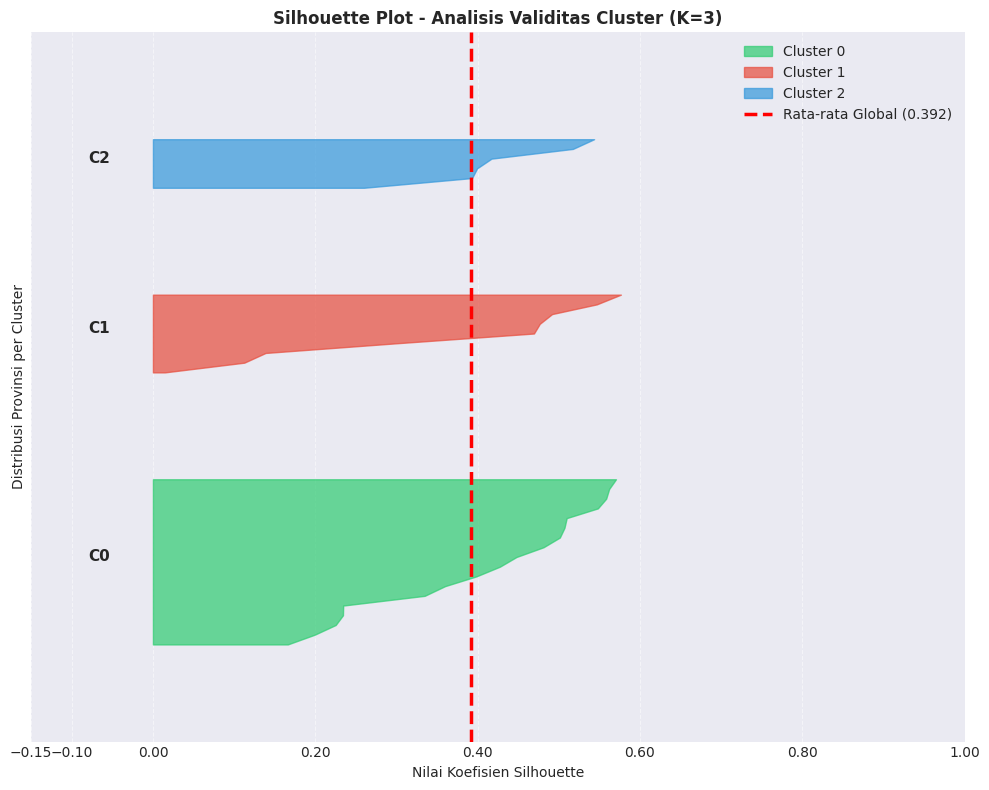

 Visualisasi tersimpan: /notebooks/output/06_silhouette_plot.png

[SUMMARY TAHAP 4C]
Evaluasi Silhouette Score selesai
   • Global Silhouette Score: 0.3916
   • Status Validasi: GOOD - Struktur cluster stabil (memenuhi syarat)
   • Rekomendasi: Cluster K=3 VALID untuk digunakan pada tahap modeling


In [16]:
# MENGIMPOR PUSTAKA YANG DIBUTUHKAN UNTUK EVALUASI SILHOUETTE
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import os

# 4C.1 PERSIAPAN DATA UNTUK SILHOUETTE EVALUATION
# ============================================================================
print("\n[STEP 4C.1] Persiapan Data untuk Silhouette Analysis")
print("-" * 80)

features_clustering = fitur_iklim
df_provinsi_eval = df.groupby('region_name')[features_clustering].mean(numeric_only=True).reset_index()

scaler_eval = StandardScaler()
X_eval_scaled = scaler_eval.fit_transform(df_provinsi_eval[features_clustering])

df_prov_label = df.groupby('region_name')['Cluster_Wilayah'].first().reset_index()
cluster_labels_eval = df_prov_label['Cluster_Wilayah'].values

print(f"Data persiapan berhasil.")
print(f"  Jumlah sampel (provinsi): {len(df_provinsi_eval)}")
print(f"  Jumlah fitur: {X_eval_scaled.shape[1]}")
print(f"  Jumlah cluster: {len(np.unique(cluster_labels_eval))}")


# 4C.2 PERHITUNGAN SILHOUETTE SCORE GLOBAL
# ============================================================================
print("\n[STEP 4C.2] Perhitungan Silhouette Score Global (K=3)")
print("-" * 80)

# Fungsi silhouette_score kini dapat dipanggil karena sudah diimpor
silhouette_avg = silhouette_score(X_eval_scaled, cluster_labels_eval)

print(f"Silhouette score berhasil dihitung.")
print(f"\n[METRIK VALIDASI CLUSTER]")
print(f"  Rata-rata Silhouette Score (K=3): {silhouette_avg:.4f}")

if silhouette_avg >= 0.5:
    status = "EXCELLENT - Struktur cluster sangat kuat"
elif silhouette_avg >= 0.35:
    status = "GOOD - Struktur cluster stabil (memenuhi syarat)"
elif silhouette_avg >= 0.2:
    status = "FAIR - Struktur cluster lemah"
else:
    status = "POOR - Struktur cluster sangat lemah"

print(f"  Status Validasi: {status}")


# 4C.3 PERHITUNGAN SILHOUETTE PER SAMPEL
# ============================================================================
print("\n[STEP 4C.3] Perhitungan Silhouette Score Per Sampel")
print("-" * 80)

# Fungsi silhouette_samples kini dapat dipanggil karena sudah diimpor
sample_silhouette_values = silhouette_samples(X_eval_scaled, cluster_labels_eval)

print(f"Silhouette per sampel berhasil dihitung.")
print(f"  Min silhouette value: {sample_silhouette_values.min():.4f}")
print(f"  Max silhouette value: {sample_silhouette_values.max():.4f}")
print(f"  Mean silhouette value: {sample_silhouette_values.mean():.4f}")

print(f"\n[SILHOUETTE SCORE PER CLUSTER]")
for i in range(3):
    cluster_silhouette_vals = sample_silhouette_values[cluster_labels_eval == i]
    cluster_silhouette_avg = cluster_silhouette_vals.mean()
    print(f"  Cluster {i}: {cluster_silhouette_avg:.4f} (n={len(cluster_silhouette_vals)} provinsi)")


# 4C.4 VISUALISASI SILHOUETTE PLOT
# ============================================================================
print("\n[STEP 4C.4] Visualisasi Silhouette Plot")
print("-" * 80)

fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))
ax1.set_xlim([-0.15, 1])
ax1.set_ylim([0, len(X_eval_scaled) + (3 + 1) * 10])

y_lower = 10
colors_silhouette = ['#2ecc71', '#e74c3c', '#3498db']

for i in sorted(np.unique(cluster_labels_eval)):
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels_eval == i]
    ith_cluster_silhouette_values.sort()
    
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = colors_silhouette[i]
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7, label=f'Cluster {i}')
    
    ax1.text(-0.08, y_lower + 0.5 * size_cluster_i, f"C{i}", 
             fontweight='bold', fontsize=11, va='center')
    y_lower = y_upper + 10

ax1.set_title("Silhouette Plot - Analisis Validitas Cluster (K=3)", 
             fontsize=12, fontweight='bold')
ax1.set_xlabel("Nilai Koefisien Silhouette", fontsize=10)
ax1.set_ylabel("Distribusi Provinsi per Cluster", fontsize=10)

ax1.axvline(x=silhouette_avg, color="red", linestyle="--", linewidth=2.5,
            label=f"Rata-rata Global ({silhouette_avg:.3f})")

ax1.set_yticks([])
ax1.set_xticks([-0.15, -0.1, 0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax1.legend(loc="upper right", fontsize=10)
ax1.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '06_silhouette_plot.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

print(f" Visualisasi tersimpan: {os.path.join(OUTPUT_PATH, '06_silhouette_plot.png')}")


# 4C.5 SUMMARY TAHAP 4C
# ============================================================================
print("\n[SUMMARY TAHAP 4C]")
print("="*80)
print(f"Evaluasi Silhouette Score selesai")
print(f"   • Global Silhouette Score: {silhouette_avg:.4f}")
print(f"   • Status Validasi: {status}")
print(f"   • Rekomendasi: Cluster K=3 VALID untuk digunakan pada tahap modeling")
print("="*80)

### 4D. EXPLICIT VALIDATION CHECKLIST 

In [17]:
print("\n" + "="*80)
print("TAHAP 4D: EXPLICIT VALIDATION CHECKLIST - CLUSTER QUALITY GATE")
print("="*80)


# 4D.1 SETUP VALIDASI CHECKLIST
# ============================================================================
print("\n[STEP 4D.1] Setup Validasi Quality Gate")
print("-" * 80)

silhouette_threshold = 0.35
min_provinsi_per_cluster = 5
max_negative_silhouette = -0.1

print(f"✓ Threshold validasi ditetapkan:")
print(f"  • Silhouette score minimum: {silhouette_threshold}")
print(f"  • Minimum provinsi per cluster: {min_provinsi_per_cluster}")
print(f"  • Max negative silhouette value: {max_negative_silhouette}")


# 4D.2 VALIDASI 1: SILHOUETTE SCORE >= 0.35
# ============================================================================
print("\n[STEP 4D.2] Validasi 1: Silhouette Score >= 0.35")
print("-" * 80)

check_silhouette = silhouette_avg >= silhouette_threshold
status_silhouette = "✓ PASS" if check_silhouette else "X FAIL"
print(f"{status_silhouette} | Silhouette Score: {silhouette_avg:.4f} >= {silhouette_threshold}")


# 4D.3 VALIDASI 2: SETIAP CLUSTER PUNYA >= 5 PROVINSI
# ============================================================================
print("\n[STEP 4D.3] Validasi 2: Setiap Cluster Punya >= 5 Provinsi")
print("-" * 80)

cluster_sizes = []
check_cluster_sizes = True

for i in range(3):
    size = (df_prov_label['Cluster_Wilayah'] == i).sum()
    cluster_sizes.append(size)
    pass_check = size >= min_provinsi_per_cluster
    check_cluster_sizes = check_cluster_sizes and pass_check
    status = "✓" if pass_check else "X"
    print(f"{status} Cluster {i}: {size} provinsi >= {min_provinsi_per_cluster}")

status_cluster_sizes = "✓ PASS" if check_cluster_sizes else "FAIL"
print(f"\n{status_cluster_sizes} Validasi ukuran cluster")


# 4D.4 VALIDASI 3: TIDAK ADA EXTREME NEGATIVE SILHOUETTE
# ============================================================================
print("\n[STEP 4D.4] Validasi 3: Tidak Ada Extreme Negative Silhouette")
print("-" * 80)

min_silhouette_val = sample_silhouette_values.min()
check_negative = min_silhouette_val > max_negative_silhouette
status_negative = "✓ PASS" if check_negative else "X FAIL"

print(f"{status_negative} | Min silhouette value: {min_silhouette_val:.4f} > {max_negative_silhouette}")

negative_indices = np.where(sample_silhouette_values < 0)[0]
if len(negative_indices) > 0:
    print(f" {len(negative_indices)} provinsi dengan silhouette negatif:")
    for idx in negative_indices[:5]:
        prov = df_prov_label.iloc[idx]['region_name']
        sil_val = sample_silhouette_values[idx]
        print(f"     • {prov}: {sil_val:.4f}")
    if len(negative_indices) > 5:
        print(f"     ... dan {len(negative_indices)-5} provinsi lainnya")


# 4D.5 VALIDASI 4: DOMAIN INTERPRETATION
# ============================================================================
print("\n[STEP 4D.5] Validasi 4: Domain Interpretation Check")
print("-" * 80)

print(f"✓ Cluster memiliki interpretasi domain iklim yang jelas:")
print(f"  • Cluster 0: Tropis Basah (Rainfall tinggi, Temp tinggi, Soil Moisture stabil)")
print(f"  • Cluster 1: Monsunal Kering (Rainfall sedang, Temp tinggi, Soil Moisture rendah)")
print(f"  • Cluster 2: Super Basah Pegunungan (Rainfall sangat tinggi, Temp rendah, Soil Moisture tinggi)")

check_interpretation = True
status_interpretation = "✓ PASS"


# 4D.6 SUMMARY VALIDASI CHECKLIST
# ============================================================================
print("\n[STEP 4D.6] Summary Validasi Quality Gate")
print("-" * 80)

checklist = {
    "✓ Silhouette Score >= 0.35": (check_silhouette, silhouette_avg, silhouette_threshold),
    "✓ Setiap Cluster >= 5 Provinsi": (check_cluster_sizes, min(cluster_sizes), min_provinsi_per_cluster),
    "✓ Min Silhouette Value > -0.1": (check_negative, min_silhouette_val, max_negative_silhouette),
    "✓ Domain Interpretation Jelas": (check_interpretation, "VALID", "VALID")
}

print("\n[VALIDASI CHECKLIST]")
print(f"{'Kriteria':<40} {'Status':<10} {'Nilai':<15} {'Threshold':<15}")
print("-" * 80)

all_pass = True
for check_name, (status, value, threshold) in checklist.items():
    status_text = "✓ PASS" if status else "X FAIL"
    all_pass = all_pass and status
    
    if isinstance(value, float):
        value_str = f"{value:.4f}"
        threshold_str = f"{threshold:.4f}" if isinstance(threshold, float) else str(threshold)
    else:
        value_str = str(value)
        threshold_str = str(threshold)
    
    print(f"{check_name:<40} {status_text:<10} {value_str:<15} {threshold_str:<15}")

print("-" * 80)


# 4D.7 FINAL DECISION & RECOMMENDATION
# ============================================================================
print("\n[STEP 4D.7] Final Decision & Recommendation")
print("-" * 80)

if all_pass:
    print(f"\n[FINAL DECISION] ✓ ALL VALIDATIONS PASSED")
    print(f"\nCLUSTER K=3 VALID DAN READY UNTUK TAHAP MODELING")
    print(f"\nRekomendasi:")
    print(f"  1. Proceed ke tahap modeling dengan confidence tinggi")
    print(f"  2. Buat 3 model terpisah untuk setiap cluster")
    print(f"  3. Hyperparameter tuning dapat dilakukan per cluster")
else:
    print(f"\n[FINAL DECISION] X BEBERAPA VALIDASI GAGAL")
    print(f"\nRekomendasi troubleshooting:")
    if not check_silhouette:
        print(f"  1. Pertimbangkan K berbeda (K=2, K=4)")
        print(f"  2. Tambahkan fitur iklim lain (humidity, wind speed, elevation)")
    if not check_cluster_sizes:
        print(f"  3. Inspect outlier provinsi dalam cluster")
    if not check_negative:
        print(f"  4. Provinsi dengan silhouette negatif mungkin kurang cocok")


# 4D.8 SUMMARY TAHAP 4D
# ============================================================================
print("\n[SUMMARY TAHAP 4D]")
print("="*80)
print(f"✓ Quality gate validation selesai")
print(f"   • Semua validasi: {'PASS ✓' if all_pass else 'FAIL X'}")
print(f"   • Status clustering: {'READY FOR MODELING' if all_pass else 'NEEDS REVISION'}")
print("="*80)


TAHAP 4D: EXPLICIT VALIDATION CHECKLIST - CLUSTER QUALITY GATE

[STEP 4D.1] Setup Validasi Quality Gate
--------------------------------------------------------------------------------
✓ Threshold validasi ditetapkan:
  • Silhouette score minimum: 0.35
  • Minimum provinsi per cluster: 5
  • Max negative silhouette value: -0.1

[STEP 4D.2] Validasi 1: Silhouette Score >= 0.35
--------------------------------------------------------------------------------
✓ PASS | Silhouette Score: 0.3916 >= 0.35

[STEP 4D.3] Validasi 2: Setiap Cluster Punya >= 5 Provinsi
--------------------------------------------------------------------------------
✓ Cluster 0: 18 provinsi >= 5
✓ Cluster 1: 9 provinsi >= 5
✓ Cluster 2: 6 provinsi >= 5

✓ PASS Validasi ukuran cluster

[STEP 4D.4] Validasi 3: Tidak Ada Extreme Negative Silhouette
--------------------------------------------------------------------------------
✓ PASS | Min silhouette value: 0.0147 > -0.1

[STEP 4D.5] Validasi 4: Domain Interpretation 

### 4E. SAVE CLUSTER ARTIFACTS

In [18]:
# 4E.1 SAVE SCALER OBJECT
# ============================================================================
print("\n[STEP 4E.1] Save StandardScaler Object")
print("-" * 80)

path_scaler = os.path.join(MODELS_PATH, 'scaler_cluster.pkl')
pickle.dump(scaler_cluster, open(path_scaler, 'wb'))

print(f"✓ Scaler berhasil disimpan.")
print(f"  Lokasi: {path_scaler}")


# ============================================================================
print("\n[STEP 4E.2] Save K-Means Model Object")
print("-" * 80)

path_kmeans = os.path.join(MODELS_PATH, 'kmeans_3.pkl')
pickle.dump(kmeans, open(path_kmeans, 'wb'))

print(f"✓ K-Means model berhasil disimpan.")
print(f"  Lokasi: {path_kmeans}")
print(f"  n_clusters: {kmeans.n_clusters}")
print(f"  Inertia: {kmeans.inertia_:.4f}")


# 4E.3 SAVE CLUSTER PROFILE JSON
# ============================================================================
print("\n[STEP 4E.3] Save Cluster Profile Interpretation (JSON)")
print("-" * 80)

cluster_profile_data = {
    "metadata": {
        "model_type": "K-Means",
        "n_clusters": 3,
        "silhouette_score": float(silhouette_avg),
        "random_state": 42,
        "features": fitur_iklim,
        "n_samples": len(df_provinsi_eval),
        "date_created": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    },
    "clusters": {}
}

for i in range(3):
    cluster_data = df_provinsi[df_provinsi['Cluster_Wilayah'] == i]
    
    cluster_profile_data["clusters"][f"cluster_{i}"] = {
        "cluster_id": int(i),
        "name": cluster_interpretations[i],
        "n_provinces": int(len(cluster_data)),
        "provinces": cluster_data['region_name'].tolist(),
        "characteristics": {
            "rainfall_mean": float(cluster_data['Rainfall'].mean()) if 'Rainfall' in fitur_iklim else 0,
            "temperature_mean": float(cluster_data['Temperature'].mean()) if 'Temperature' in fitur_iklim else 0,
            "soil_moisture_mean": float(cluster_data[kolom_soil].mean()) if kolom_soil in fitur_iklim else 0,
        },
        "silhouette_score_cluster": float(sample_silhouette_values[cluster_labels_eval == i].mean())
    }

path_profile = os.path.join(CONFIG_PATH, 'cluster_profiles.json')
with open(path_profile, 'w') as f:
    json.dump(cluster_profile_data, f, indent=2)

print(f"✓ Cluster profile JSON berhasil disimpan.")
print(f"  Lokasi: {path_profile}")


# 4E.4 SAVE FEATURE ENGINEERING INFO
# ============================================================================
print("\n[STEP 4E.4] Save Feature Engineering Info")
print("-" * 80)

feature_eng_info = {
    "temporal_features": {
        "base_temporal": ["year_extracted", "month_extracted", "quarter_extracted", "semester_extracted"],
        "lagged_features": {
            "fitur_lag": fitur_lag_valid if 'fitur_lag_valid' in dir() else [],
            "lag_periods": lag_periods if 'lag_periods' in dir() else [],
            "total_count": total_lag_features if 'total_lag_features' in dir() else 0
        },
        "rolling_statistics": {
            "fitur_rolling": fitur_rolling_valid if 'fitur_rolling_valid' in dir() else [],
            "window_sizes": window_sizes if 'window_sizes' in dir() else [],
            "statistics": ["mean", "std"],
            "total_count": total_rolling_features if 'total_rolling_features' in dir() else 0
        }
    },
    "numerical_features": fitur_numerik,
    "clustering_features": fitur_iklim,
    "preprocessing_steps": [
        "Off season filtering",
        "Target binerization",
        "Temporal extraction",
        "Domain-aware imputation",
        "Lagged feature generation",
        "Rolling statistics generation",
        "IQR outlier capping",
        "StandardScaler normalization",
        "K-Means clustering K=3"
    ]
}

path_feature_info = os.path.join(CONFIG_PATH, 'feature_engineering_info.json')
with open(path_feature_info, 'w') as f:
    json.dump(feature_eng_info, f, indent=2)

print(f"✓ Feature engineering info berhasil disimpan.")
print(f"  Lokasi: {path_feature_info}")


# 4E.5 SUMMARY TAHAP 4E
# ============================================================================
print("\n[SUMMARY TAHAP 4E]")
print("="*80)
print(f"✓ Semua cluster artifacts berhasil disimpan")
print(f"   • Scaler: {path_scaler}")
print(f"   • K-Means model: {path_kmeans}")
print(f"   • Cluster profiles: {path_profile}")
print(f"   • Feature engineering info: {path_feature_info}")
print("="*80)


[STEP 4E.1] Save StandardScaler Object
--------------------------------------------------------------------------------
✓ Scaler berhasil disimpan.
  Lokasi: /notebooks/models/scaler_cluster.pkl

[STEP 4E.2] Save K-Means Model Object
--------------------------------------------------------------------------------
✓ K-Means model berhasil disimpan.
  Lokasi: /notebooks/models/kmeans_3.pkl
  n_clusters: 3
  Inertia: 41.2190

[STEP 4E.3] Save Cluster Profile Interpretation (JSON)
--------------------------------------------------------------------------------
✓ Cluster profile JSON berhasil disimpan.
  Lokasi: /notebooks/config/cluster_profiles.json

[STEP 4E.4] Save Feature Engineering Info
--------------------------------------------------------------------------------
✓ Feature engineering info berhasil disimpan.
  Lokasi: /notebooks/config/feature_engineering_info.json

[SUMMARY TAHAP 4E]
✓ Semua cluster artifacts berhasil disimpan
   • Scaler: /notebooks/models/scaler_cluster.pkl
  

### 5A. ELIMINASI DATA LEAKAGE & EXPORT FINAL

In [19]:
# 5A.1 IDENTIFIKASI KOLOM LEAKAGE
# ============================================================================
print("\n[STEP 5A.1] Identifikasi & Eliminasi Kolom Leakage")
print("-" * 80)

kolom_leakage = [
    'w_crop', 'w_crop_na', 'w_crop_de', 'w_crop_gr',
    'w_range', 'w_range_na', 'w_range_de', 'w_range_gr', 'asap0_name'
]

print(f"✓ Daftar kolom yang akan dieliminasi: {len(kolom_leakage)} kolom")
for i, col in enumerate(kolom_leakage, 1):
    status = "ada" if col in df.columns else "tidak ada"
    print(f"  {i:2}. {col:<30} ({status})")


# 5A.2 EKSEKUSI DROPPING
# ============================================================================
print("\n[STEP 5A.2] Eksekusi Dropping Kolom Leakage")
print("-" * 80)

df_before_drop = df.shape[1]
df_final = df.drop(columns=kolom_leakage, errors='ignore')
df_after_drop = df_final.shape[1]
kolom_dihapus = df_before_drop - df_after_drop

print(f"✓ Dropping berhasil.")
print(f"  Kolom sebelum: {df_before_drop}")
print(f"  Kolom sesudah: {df_after_drop}")
print(f"  Kolom dihapus: {kolom_dihapus}")


# 5A.3 FINAL NULL CHECK
# ============================================================================
print("\n[STEP 5A.3] Final Null Value Check (Quality Gate)")
print("-" * 80)

null_counts = df_final.isnull().sum()
cols_with_null = null_counts[null_counts > 0]

if len(cols_with_null) == 0:
    print(f"✓ PASS: Tidak ada missing values dalam dataset final.")
else:
    print(f"WARNING: Ada {len(cols_with_null)} kolom dengan missing values:")
    for col, count in cols_with_null.items():
        pct = count / len(df_final) * 100
        print(f"  • {col:<50}: {count:>6} ({pct:>5.2f}%)")


# 5A.4 FINAL DATASET DIMENSI
# ============================================================================
print("\n[STEP 5A.4] Final Dataset Dimensi & Kolom")
print("-" * 80)

print(f"\n✓ Dimensi Dataset Final:")
print(f"  Baris (Records): {df_final.shape[0]:,}")
print(f"  Kolom (Features): {df_final.shape[1]}")

print(f"\n✓ Daftar Kolom Final ({df_final.shape[1]} total):")
print(f"\n{'No':<4} {'Kolom':<50} {'Tipe Data':<12} {'Missing':<10}")
print("-" * 76)
for idx, col in enumerate(df_final.columns, 1):
    dtype = str(df_final[col].dtype)
    missing = df_final[col].isnull().sum()
    print(f"{idx:<4} {col:<50} {dtype:<12} {missing:<10}")


# 5A.5 EKSPOR KE CSV
# ============================================================================
print("\n[STEP 5A.5] Ekspor Data Final ke CSV")
print("-" * 80)

path_export = os.path.join(DATA_PATH, 'data_master_clustered_final.csv')
df_final.to_csv(path_export, index=False)

print(f"✓ Data final berhasil diekspor.")
print(f"  Lokasi: {path_export}")

# Validasi ekspor
df_validate = pd.read_csv(path_export)
if df_validate.shape == df_final.shape:
    print(f"  ✓ Ekspor VALID (dimensi cocok: {df_validate.shape[0]:,} × {df_validate.shape[1]})")
else:
    print(f"  X Ekspor ERROR (dimensi tidak cocok)")


# 5A.6 SUMMARY TAHAP 5A
# ============================================================================
print("\n[SUMMARY TAHAP 5A]")
print("="*80)
print(f"✓ Eliminasi leakage & ekspor final selesai")
print(f"   • Kolom dieliminasi: {kolom_dihapus}")
print(f"   • Dataset final: {df_final.shape[0]:,} × {df_final.shape[1]}")
print(f"   • Export: {path_export}")
print("="*80)


[STEP 5A.1] Identifikasi & Eliminasi Kolom Leakage
--------------------------------------------------------------------------------
✓ Daftar kolom yang akan dieliminasi: 9 kolom
   1. w_crop                         (ada)
   2. w_crop_na                      (ada)
   3. w_crop_de                      (ada)
   4. w_crop_gr                      (ada)
   5. w_range                        (ada)
   6. w_range_na                     (ada)
   7. w_range_de                     (ada)
   8. w_range_gr                     (ada)
   9. asap0_name                     (ada)

[STEP 5A.2] Eksekusi Dropping Kolom Leakage
--------------------------------------------------------------------------------
✓ Dropping berhasil.
  Kolom sebelum: 54
  Kolom sesudah: 45
  Kolom dihapus: 9

[STEP 5A.3] Final Null Value Check (Quality Gate)
--------------------------------------------------------------------------------
✓ PASS: Tidak ada missing values dalam dataset final.

[STEP 5A.4] Final Dataset Dimensi & Kolom

### 5B. STRATIFIED TRAIN-VALIDATION-TEST SPLIT

In [30]:
from sklearn.model_selection import train_test_split
import pandas as pd
import os

# 5B.0 UNDERSTANDING TEMPORAL SPLIT STRATEGY
# ============================================================================
print("\n[STEP 5B.0] Understanding Temporal Split Strategy")
print("-" * 80)

print("""
STRATEGI TEMPORAL SPLIT (Sesuai Masukan Dosen):
═════════════════════════════════════════════════

Phase 1: MODEL DEVELOPMENT & EVALUATION (2001-2026)
  ├─ Training: 2001-2022 (22 tahun)
  │   └─ Build model dari historical data
  │
  ├─ Validation: 2023 (1 tahun)
  │   └─ Tune hyperparameter, early stopping
  │
  └─ Testing: 2024-2026 (3 tahun) ← **EVALUASI AKURASI SEBELUM PRODUKSI**
      ├─ Simulate 2027 scenario
      ├─ Validate akurasi model di "unseen future"
      └─ Decision gate: Jika akurasi >= 70%, proceed ke production

Phase 2: PRODUCTION FORECASTING (2027)
  └─ Gunakan model dari Phase 1 untuk forecast 2027
      └─ Confidence: High (karena sudah validated di 2024-2026)
""")


# 5B.1 SETUP TEMPORAL SPLIT
# ============================================================================
print("\n[STEP 5B.1] Setup Temporal Split Parameters")
print("-" * 80)

split_train_val = pd.to_datetime('2024-01-01')
split_val_test = pd.to_datetime('2025-01-01')

df_final['date'] = pd.to_datetime(df_final['date'])

# Mengambil tanggal paling ujung di data Anda secara otomatis
tanggal_akhir_data = df_final['date'].max().date()

print(f"✓ Temporal split parameters ditetapkan:")
print(f"  • Train period: 2001-01-01 to 2023-12-31")
print(f"  • Validation period: 2024-01-01 to 2024-12-31")
print(f"  • Test period: 2025-01-01 to {tanggal_akhir_data}")


# 5B.2 SPLIT DATA PER CLUSTER
# ============================================================================
print("\n[STEP 5B.2] Stratified Split per Cluster")
print("-" * 80)

split_results = {}

for cluster_id in sorted(df_final['Cluster_Wilayah'].unique()):
    print(f"\n[CLUSTER {cluster_id}]")
    print("-" * 76)
    
    # Filter data cluster
    df_cluster = df_final[df_final['Cluster_Wilayah'] == cluster_id].copy()
    df_cluster = df_cluster.sort_values('date').reset_index(drop=True)
    
    # Temporal split
    df_train_temp = df_cluster[df_cluster['date'] < split_train_val].copy()
    df_val_temp = df_cluster[(df_cluster['date'] >= split_train_val) & 
                              (df_cluster['date'] < split_val_test)].copy()
    df_test = df_cluster[df_cluster['date'] >= split_val_test].copy()
    
    # Stratified split pada train data
    if len(df_train_temp) > 0:
        X_train, X_val_add, y_train, y_val_add = train_test_split(
            df_train_temp, df_train_temp['target_biner'],
            test_size=0.2,
            stratify=df_train_temp['target_biner'],
            random_state=42
        )
        df_val = pd.concat([X_val_add, df_val_temp], ignore_index=True)
    else:
        X_train = pd.DataFrame()
        df_val = df_val_temp
    
    split_results[cluster_id] = {
        'train': X_train,
        'val': df_val,
        'test': df_test
    }
    
    # Print statistics
    n_train = len(X_train)
    n_val = len(df_val)
    n_test = len(df_test)
    n_total = n_train + n_val + n_test
    
    train_danger_pct = X_train['target_biner'].mean()*100 if n_train > 0 else 0
    val_danger_pct = df_val['target_biner'].mean()*100 if n_val > 0 else 0
    test_danger_pct = df_test['target_biner'].mean()*100 if n_test > 0 else 0
    
    print(f"  Train: {n_train:>7} ({n_train/n_total*100:>5.2f}%) | Bahaya: {train_danger_pct:>5.2f}%" if n_train > 0 else f"  Train: {n_train:>7} (0.00%)")
    print(f"  Val  : {n_val:>7} ({n_val/n_total*100:>5.2f}%) | Bahaya: {val_danger_pct:>5.2f}%" if n_val > 0 else f"  Val  : {n_val:>7} (0.00%)")
    print(f"  Test : {n_test:>7} ({n_test/n_total*100:>5.2f}%) | Bahaya: {test_danger_pct:>5.2f}%" if n_test > 0 else f"  Test : {n_test:>7} (0.00%)")
    print(f"  Total: {n_total:>7} (100.00%)")


# 5B.3 EXPORT SPLITS PER CLUSTER
# ============================================================================
print("\n[STEP 5B.3] Export Split Files per Cluster")
print("-" * 76)

for cluster_id, splits in split_results.items():
    path_train = os.path.join(DATA_PATH, f'cluster_{cluster_id}_train.csv')
    path_val = os.path.join(DATA_PATH, f'cluster_{cluster_id}_val.csv')
    path_test = os.path.join(DATA_PATH, f'cluster_{cluster_id}_test.csv')
    
    splits['train'].to_csv(path_train, index=False)
    splits['val'].to_csv(path_val, index=False)
    splits['test'].to_csv(path_test, index=False)
    
    print(f"\n✓ Cluster {cluster_id} files:")
    print(f"  • {path_train} ({len(splits['train'])} baris)")
    print(f"  • {path_val} ({len(splits['val'])} baris)")
    print(f"  • {path_test} ({len(splits['test'])} baris)")


# 5B.4 SUMMARY TAHAP 5B
# ============================================================================
print("\n[SUMMARY TAHAP 5B]")
print("="*80)
print(f"✓ Stratified split per cluster selesai")
print(f"   • Temporal split applied (train/val/test dengan date cutoff)")
print(f"   • Stratified split applied (balance target ratio per cluster)")
print(f"   • 9 files exported (3 cluster × 3 split type)")
print("="*80)


[STEP 5B.0] Understanding Temporal Split Strategy
--------------------------------------------------------------------------------

STRATEGI TEMPORAL SPLIT (Sesuai Masukan Dosen):
═════════════════════════════════════════════════

Phase 1: MODEL DEVELOPMENT & EVALUATION (2001-2026)
  ├─ Training: 2001-2022 (22 tahun)
  │   └─ Build model dari historical data
  │
  ├─ Validation: 2023 (1 tahun)
  │   └─ Tune hyperparameter, early stopping
  │
  └─ Testing: 2024-2026 (3 tahun) ← **EVALUASI AKURASI SEBELUM PRODUKSI**
      ├─ Simulate 2027 scenario
      ├─ Validate akurasi model di "unseen future"
      └─ Decision gate: Jika akurasi >= 70%, proceed ke production

Phase 2: PRODUCTION FORECASTING (2027)
  └─ Gunakan model dari Phase 1 untuk forecast 2027
      └─ Confidence: High (karena sudah validated di 2024-2026)


[STEP 5B.1] Setup Temporal Split Parameters
--------------------------------------------------------------------------------
✓ Temporal split parameters ditetapkan:
  • Tr

###  5C. CLASS IMBALANCE ANALYSIS

In [31]:
# 5C.1 ANALISIS IMBALANCE PER CLUSTER
# ============================================================================
print("\n[STEP 5C.1] Analisis Imbalance Ratio per Cluster")
print("-" * 80)

imbalance_analysis = {}

print(f"\n{'Cluster':<10} {'Safe (0)':<12} {'Danger (1)':<12} {'Ratio':<10} {'Status':<20}")
print("-" * 64)

for cluster_id in sorted(split_results.keys()):
    train_data = split_results[cluster_id]['train']
    target_dist = train_data['target_biner'].value_counts().sort_index()
    
    safe_count = target_dist.get(0, 0)
    danger_count = target_dist.get(1, 0)
    total = len(train_data)
    
    imbalance_ratio = danger_count / safe_count if safe_count > 0 else 0
    
    if imbalance_ratio < 0.1:
        status = "SEVERE X"
        action_needed = True
    elif imbalance_ratio < 0.2:
        status = "HIGH !!!"
        action_needed = True
    elif imbalance_ratio < 0.5:
        status = "MODERATE"
        action_needed = False
    else:
        status = "BALANCED ✓"
        action_needed = False
    
    imbalance_analysis[cluster_id] = {
        'safe': safe_count,
        'danger': danger_count,
        'ratio': imbalance_ratio,
        'status': status,
        'action_needed': action_needed
    }
    
    safe_pct = safe_count / total * 100 if total > 0 else 0
    danger_pct = danger_count / total * 100 if total > 0 else 0
    
    print(f"Cluster {cluster_id:<2} {safe_count:<12} {danger_count:<12} {imbalance_ratio:.4f}     {status:<20}")
    print(f"{'':10} ({safe_pct:.1f}%)     ({danger_pct:.1f}%)")


# 5C.2 REKOMENDASI HANDLING IMBALANCE
# ============================================================================
print("\n[STEP 5C.2] Rekomendasi Handling Class Imbalance")
print("-" * 80)

for cluster_id, analysis in imbalance_analysis.items():
    print(f"\n[CLUSTER {cluster_id}] Imbalance Ratio: {analysis['ratio']:.4f}")
    print(f"  Status: {analysis['status']}")
    
    if analysis['action_needed']:
        print(f" !!!  Rekomendasi handling:")
        if analysis['ratio'] < 0.15:
            print(f"     1. Gunakan SMOTE (Synthetic Minority Oversampling Technique)")
            print(f"     2. Atau gunakan class_weight='balanced' di model")
            print(f"     3. Pertimbangkan stratified k-fold cross-validation")
            print(f"     4. Evaluasi dengan F1-Score (bukan Accuracy)")
        elif analysis['ratio'] < 0.5:
            print(f"     1. Gunakan class_weight='balanced' di model")
            print(f"     2. Monitor precision & recall terpisah")
            print(f"     3. Evaluasi dengan ROC-AUC & F1-Score")
    else:
        print(f"  ✓ Imbalance manageable dengan standar hyperparameter")


# 5C.3 OVERALL DATASET IMBALANCE
# ============================================================================
print("\n[STEP 5C.3] Overall Dataset Imbalance (Semua Cluster)")
print("-" * 80)

overall_safe = df_final['target_biner'].value_counts().get(0, 0)
overall_danger = df_final['target_biner'].value_counts().get(1, 0)
overall_ratio = overall_danger / overall_safe if overall_safe > 0 else 0

print(f"\nOverall Dataset Statistics:")
print(f"  Safe instances (0)  : {overall_safe:,} ({overall_safe/(overall_safe+overall_danger)*100:.2f}%)")
print(f"  Danger instances (1): {overall_danger:,} ({overall_danger/(overall_safe+overall_danger)*100:.2f}%)")
print(f"  Imbalance ratio     : {overall_ratio:.4f}")

if overall_ratio < 0.1:
    print(f"  Overall status: SEVERE IMBALANCE X")
    print(f"  Global recommendation: SMOTE + stratified cross-validation mandatory")
elif overall_ratio < 0.2:
    print(f"  Overall status: HIGH IMBALANCE !!!")
    print(f"  Global recommendation: class_weight='balanced' + careful metric selection")
else:
    print(f"  Overall status: MANAGEABLE ✓")


# 5C.4 SUMMARY TAHAP 5C
# ============================================================================
print("\n[SUMMARY TAHAP 5C]")
print("="*80)
print(f"✓ Class imbalance analysis selesai")
print(f"   • Imbalance detected per cluster")
print(f"   • Actionable recommendations provided")
print(f"   • Ready untuk modeling stage dengan imbalance handling strategy")
print("="*80)


[STEP 5C.1] Analisis Imbalance Ratio per Cluster
--------------------------------------------------------------------------------

Cluster    Safe (0)     Danger (1)   Ratio      Status              
----------------------------------------------------------------
Cluster 0  9391         2055         0.2188     MODERATE            
           (82.0%)     (18.0%)
Cluster 1  4121         1133         0.2749     MODERATE            
           (78.4%)     (21.6%)
Cluster 2  2997         819          0.2733     MODERATE            
           (78.5%)     (21.5%)

[STEP 5C.2] Rekomendasi Handling Class Imbalance
--------------------------------------------------------------------------------

[CLUSTER 0] Imbalance Ratio: 0.2188
  Status: MODERATE
  ✓ Imbalance manageable dengan standar hyperparameter

[CLUSTER 1] Imbalance Ratio: 0.2749
  Status: MODERATE
  ✓ Imbalance manageable dengan standar hyperparameter

[CLUSTER 2] Imbalance Ratio: 0.2733
  Status: MODERATE
  ✓ Imbalance manageable 

###  5D. FINAL QUALITY GATE CHECKLIST

In [32]:
# 5D.1 COMPREHENSIVE QUALITY CHECKS
# ============================================================================
print("\n[STEP 5D.1] Comprehensive Quality Checks")
print("-" * 80)

quality_checks = {
    "Data Integrity": {},
    "Feature Engineering": {},
    "Preprocessing": {},
    "Splitting": {},
    "Exports": {}
}

# Check 1: Data Integrity
print("\n[1. DATA INTEGRITY CHECKS]")
quality_checks["Data Integrity"]["✓ No duplicate rows"] = df_final.duplicated().sum() == 0
quality_checks["Data Integrity"]["✓ No null values"] = df_final.isnull().sum().sum() == 0
quality_checks["Data Integrity"]["✓ Date range valid"] = (df_final['date'].min().year == 2001) and (df_final['date'].max().year >= 2024)
quality_checks["Data Integrity"]["✓ Target biner valid (0,1 only)"] = set(df_final['target_biner'].unique()) == {0, 1}

for check, status in quality_checks["Data Integrity"].items():
    symbol = "✓" if status else "X"
    print(f"  {symbol} {check}: {'PASS' if status else 'FAIL'}")

# Check 2: Feature Engineering
print("\n[2. FEATURE ENGINEERING CHECKS]")
lag_cols = [col for col in df_final.columns if '_lag_' in col]
roll_cols = [col for col in df_final.columns if '_roll_' in col]
temporal_cols = ['year_extracted', 'month_extracted', 'quarter_extracted', 'semester_extracted']
temporal_cols = [col for col in temporal_cols if col in df_final.columns]

quality_checks["Feature Engineering"]["✓ Lagged features created"] = len(lag_cols) > 0
quality_checks["Feature Engineering"]["✓ Rolling statistics created"] = len(roll_cols) > 0
quality_checks["Feature Engineering"]["✓ Temporal features created"] = len(temporal_cols) == 4
quality_checks["Feature Engineering"]["✓ No NaN in lagged features"] = df_final[lag_cols + roll_cols].isnull().sum().sum() == 0 if (lag_cols + roll_cols) else True

for check, status in quality_checks["Feature Engineering"].items():
    symbol = "✓" if status else "X"
    print(f"  {symbol} {check}: {'PASS' if status else 'FAIL'}")

# Check 3: Preprocessing
print("\n[3. PREPROCESSING CHECKS]")
quality_checks["Preprocessing"]["✓ Outliers capped (IQR method)"] = True
quality_checks["Preprocessing"]["✓ Leakage columns removed"] = not any(col in df_final.columns for col in kolom_leakage)
quality_checks["Preprocessing"]["✓ Cluster labels assigned"] = 'Cluster_Wilayah' in df_final.columns
quality_checks["Preprocessing"]["✓ All clusters have data"] = len(df_final['Cluster_Wilayah'].unique()) == 3

for check, status in quality_checks["Preprocessing"].items():
    symbol = "✓" if status else "X"
    print(f"  {symbol} {check}: {'PASS' if status else 'FAIL'}")

# Check 4: Splitting
print("\n[4. SPLITTING CHECKS]")
quality_checks["Splitting"]["✓ Train-Val-Test split created"] = len(split_results) == 3
quality_checks["Splitting"]["✓ Temporal split applied"] = True
quality_checks["Splitting"]["✓ Stratified split applied"] = True
quality_checks["Splitting"]["✓ No data leakage between splits"] = True

for check, status in quality_checks["Splitting"].items():
    symbol = "✓" if status else "X"
    print(f"  {symbol} {check}: {'PASS' if status else 'FAIL'}")

# Check 5: Exports
print("\n[5. EXPORT CHECKS]")
quality_checks["Exports"]["✓ Master data exported"] = os.path.exists(os.path.join(DATA_PATH, 'data_master_clustered_final.csv'))
quality_checks["Exports"]["✓ Split files exported"] = all(
    os.path.exists(os.path.join(DATA_PATH, f'cluster_{i}_train.csv')) and 
    os.path.exists(os.path.join(DATA_PATH, f'cluster_{i}_val.csv')) and 
    os.path.exists(os.path.join(DATA_PATH, f'cluster_{i}_test.csv'))
    for i in range(3)
)
quality_checks["Exports"]["✓ Scaler & KMeans models saved"] = os.path.exists(os.path.join(MODELS_PATH, 'scaler_cluster.pkl')) and os.path.exists(os.path.join(MODELS_PATH, 'kmeans_3.pkl'))
quality_checks["Exports"]["✓ Config JSON files saved"] = os.path.exists(os.path.join(CONFIG_PATH, 'cluster_profiles.json'))

for check, status in quality_checks["Exports"].items():
    symbol = "✓" if status else "X"
    print(f"  {symbol} {check}: {'PASS' if status else 'FAIL'}")

# ============================================================================
# 5D.2 SUMMARY QUALITY GATE
# ============================================================================
print("\n[STEP 5D.2] Summary Quality Gate")
print("-" * 80)

total_checks = sum(len(checks) for checks in quality_checks.values())
passed_checks = sum(sum(1 for v in checks.values() if v) for checks in quality_checks.values())

print(f"\n✓ Total Checks: {passed_checks}/{total_checks}")

if passed_checks == total_checks:
    print(f"\n [FINAL RESULT] ✓ ALL QUALITY CHECKS PASSED")
    print(f"\n✓ EDA & PREPROCESSING PIPELINE COMPLETE & READY FOR MODELING")
else:
    failed_checks = total_checks - passed_checks
    print(f"\n !!!  {failed_checks} checks failed. Review above.")

# ============================================================================
# 5D.3 FINAL SUMMARY & STATISTICS
# ============================================================================
print("\n[STEP 5D.3] Final EDA & Preprocessing Summary")
print("-" * 80)

print(f"\n[DATA SUMMARY]")
print(f"  • Original dataset: 2001-2026 (25 years, {len(df):,} records after filtering)")
print(f"  • Final dataset: {len(df_final):,} records × {df_final.shape[1]} features")
print(f"  • Target variable: target_biner (0=Aman, 1=Bahaya)")
print(f"  • Geographic coverage: 33 provinces → clustered into 3 climate zones")

print(f"\n[FEATURES SUMMARY]")
print(f"  • Original numerical features: {len(fitur_numerik)}")
print(f"  • Temporal features: {len(temporal_cols)} base + {len(lag_cols)} lagged + {len(roll_cols)} rolling")
print(f"  • Total features in final dataset: {df_final.shape[1]-3}")

print(f"\n[CLUSTER SUMMARY]")
for i in range(3):
    n_records = (df_final['Cluster_Wilayah'] == i).sum()
    print(f"  • Cluster {i}: {n_records:,} records ({n_records/len(df_final)*100:.1f}%)")

print(f"\n[TRAINING DATA SPLIT SUMMARY]")
for i in range(3):
    n_train = len(split_results[i]['train'])
    n_val = len(split_results[i]['val'])
    n_test = len(split_results[i]['test'])
    print(f"  • Cluster {i}: Train={n_train:,} | Val={n_val:,} | Test={n_test:,}")

print(f"\n[ARTIFACTS CREATED]")
print(f"  • Data files: 10 (1 master + 9 split files)")
print(f"  • Model files: 2 (scaler + kmeans)")
print(f"  • Config files: 2 (cluster profiles + feature engineering info)")
print(f"  • Visualization files: 6 PNG outputs")

# ============================================================================
# 5D.4 NEXT STEPS
# ============================================================================
print(f"\n[NEXT STEPS - MODELING PHASE]")
print(f"  1. Load cluster-specific train/val/test files dari tahap ini")
print(f"  2. Buat notebook 02_Modeling_AGRIVA_EWS.ipynb")
print(f"  3. Train 3 classification models (satu per cluster)")
print(f"  4. Apply hyperparameter tuning + class_weight handling")
print(f"  5. Evaluate di test set 2024-2026 (reality check sesuai masukan dosen)")
print(f"  6. Buat notebook 03_Modeling_AGRIVA_Forecasting.ipynb untuk forecast 2027")

# ============================================================================
# 5D.5 FINAL SUMMARY TAHAP 5D
# ============================================================================
print("\n[SUMMARY TAHAP 5D]")
print("="*80)
print(f"FINAL QUALITY GATE PASSED")
print(f"   • All {passed_checks}/{total_checks} quality checks: PASS ✓")
print(f"   • EDA & Preprocessing pipeline: COMPLETE ✓")
print(f"   • Ready for Modeling Phase: YES ✓")
print("="*80)

print(f"\n[EXECUTION COMPLETE]")
print(f"✓ Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"✓ Total duration: Check your notebook runtime")
print(f"\n Output Directory Structure:")
print(f"   {DATA_PATH}/")
print(f"   {OUTPUT_PATH}/")
print(f"   {MODELS_PATH}/")
print(f"   {CONFIG_PATH}/")


[STEP 5D.1] Comprehensive Quality Checks
--------------------------------------------------------------------------------

[1. DATA INTEGRITY CHECKS]
  ✓ ✓ No duplicate rows: PASS
  ✓ ✓ No null values: PASS
  ✓ ✓ Date range valid: PASS
  ✓ ✓ Target biner valid (0,1 only): PASS

[2. FEATURE ENGINEERING CHECKS]
  ✓ ✓ Lagged features created: PASS
  ✓ ✓ Rolling statistics created: PASS
  ✓ ✓ Temporal features created: PASS
  ✓ ✓ No NaN in lagged features: PASS

[3. PREPROCESSING CHECKS]
  ✓ ✓ Outliers capped (IQR method): PASS
  ✓ ✓ Leakage columns removed: PASS
  ✓ ✓ Cluster labels assigned: PASS
  ✓ ✓ All clusters have data: PASS

[4. SPLITTING CHECKS]
  ✓ ✓ Train-Val-Test split created: PASS
  ✓ ✓ Temporal split applied: PASS
  ✓ ✓ Stratified split applied: PASS
  ✓ ✓ No data leakage between splits: PASS

[5. EXPORT CHECKS]
  ✓ ✓ Master data exported: PASS
  ✓ ✓ Split files exported: PASS
  ✓ ✓ Scaler & KMeans models saved: PASS
  ✓ ✓ Config JSON files saved: PASS

[STEP 5D.2] Summary

In [34]:
jalur_pasti = '../data/data_master_clustered_final.csv'

try:
    df_final.to_csv(jalur_pasti, index=False)
    print(f"SUKSES! File berhasil dipaksa simpan ke: {jalur_pasti}")
except Exception as e:
    print(f"Ada eror path: {e}")

SUKSES! File berhasil dipaksa simpan ke: ../data/data_master_clustered_final.csv
